In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import pandas as pd
import datetime
import numpy as np
import re
import cartopy.crs as ccrs
import cartopy
import cartopy.geodesic as cgeodesic
import xarray as xr
import warnings
from scipy.stats import linregress
from scipy.stats import gaussian_kde

In [2]:
def read_tracks(filename=None, var_names=None):
    regex_clean = re.compile(r'&')
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    assert len(lines) > 0, "File does not exist or is empty"

    i_start = [i for i, line in enumerate(lines) if line.startswith('TRACK_ID')]
    n_tracks = len(i_start)

    tracks = []
    for ii in range(n_tracks):
        start_ = i_start[ii] + 2
        n_points = int(lines[i_start[ii] + 1].split()[1])
        track_lines = lines[start_:start_ + n_points]

        track_lines = [regex_clean.sub('', line).split() for line in track_lines]
        data = np.array(track_lines, dtype=float)
        data[data == 1e25] = np.nan

        columns = ['ID', 'start_time', 'median_time', 'name']
        split_line = lines[i_start[ii]].split()
        
        id_id = split_line[1] if len(split_line) > 1 else 'unknown'
        start_time = split_line[3] if len(split_line) > 3 else 'unknown'
        median_time = split_line[5] if len(split_line) > 5 else 'unknown'
        name_storm = split_line[9] if len(split_line) > 9 else 'unknown'
        
        df = pd.DataFrame(data, columns=var_names[:data.shape[1]])
        df['ID'] = id_id
        df['start_time'] = start_time
        df['median_time'] = median_time
        df['name'] = name_storm
        
        tracks.append(df)

    result = pd.concat(tracks, ignore_index=True)
    result['ID'] = result['ID'].astype('category')

    return result

In [3]:
def calc_speed_dir(data, freq):
    geodesic = cgeodesic.Geodesic()

    distances = []
    speeds = []
    bearings = []
    indices = []

    for name, group in data.groupby('ID'):
        if len(group) < 2:
            continue

        for i in range(len(group) - 1):
            out = geodesic.inverse(
                [group['lon_vor'].iloc[i], group['lat_vor'].iloc[i]],
                [group['lon_vor'].iloc[i+1], group['lat_vor'].iloc[i+1]])

            distance = out[0, 0] * 1e-3  # Convert meters to kilometers
            speed = out[0, 0] / (freq * 3600)  # Calculate speed
            bearing = out[0, 1]  # Azimuth bearing

            distances.append(distance)
            speeds.append(speed)
            bearings.append(bearing)
            indices.append(group.index[i])

    data.loc[indices, 'distance'] = distances
    data.loc[indices, 'speed'] = speeds
    data.loc[indices, 'bearing'] = bearings

    return data

def adjust_bearing(bearing):
    if -180 <= bearing < 0:
        return bearing + 360
    return bearing

In [4]:
trx_all = pd.DataFrame()

for i in range(1982, 2022):
    #file_path = f'Track/ERA5_VOR850_1hr_oct-mar{i}{i+1}_NORTHSEA_minwindspeed25.csv'
    file_path = f'Track/ERA5_VOR850_1hr_oct-mar{i}{i+1}_NORTHSEA_minwindspeed25_longlive.csv'
    trx_data = pd.read_csv(file_path)
    trx_all = pd.concat([trx_all, trx_data], ignore_index=True)

trx_all = calc_speed_dir(trx_all, 1)
trx_all['bearing'] = trx_all['bearing'].apply(adjust_bearing)
trx_all['uniq_id'] = list(zip(trx_all['ID'], trx_all['season']))
print('Number of unique storms (ID and season):', trx_all['uniq_id'].nunique())

trx_all['lon_vor'] = ((trx_all['lon_vor'] + 180) % 360) - 180
trx_all['speed'] = pd.to_numeric(trx_all['speed'], errors='coerce')
trx_all['speed'].fillna(trx_all['speed'].mean(), inplace=True)

trx_all.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season,duration
0,0,1982-10-19 13:00:00,1.534199,58.076061,2.661184,NaN,NaN,1003.516,4.21875,62.52924,40.63476,3.37500,61.96718,20.57130,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
1,1,1982-10-19 14:00:00,2.616141,57.525417,2.881066,NaN,NaN,1005.743,4.78125,62.24821,39.33882,3.93750,62.81027,20.07453,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
2,2,1982-10-19 15:00:00,3.408462,57.387611,3.076569,NaN,NaN,1006.686,4.78125,62.52924,35.92666,4.21875,63.37233,18.02655,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
3,3,1982-10-19 16:00:00,3.932111,57.438416,3.175046,NaN,NaN,1006.377,5.06250,62.52924,32.58338,4.50000,61.96718,18.71960,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00
4,4,1982-10-19 17:00:00,4.410720,57.631748,3.225164,NaN,NaN,1005.896,5.34375,62.81027,30.18725,5.06250,62.24821,17.47002,2641,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00


In [252]:
vor_perc = trx_all.groupby('season')['var_mslp'].apply(lambda x: x.quantile(0.9))
vor_mean = trx_all['var_mslp'].mean()
vor_std = trx_all['var_mslp'].std()
#print('mean:', vor_mean, 'std:', vor_std)

ssi = (vor_perc.values - vor_mean) / vor_std
#ssi = vor_perc

In [279]:
from scipy.stats import linregress

range_season = np.arange(0,40,1)
slope, intercept, r_value, p_value, std_err = linregress(range_season, ssi)
Y_pred = intercept + slope * range_season

In [140]:
def storm_direction(group):
    westerly_count = sum((group['bearing'] >= 30) & (group['bearing'] <= 120))
    northerly_count = sum((group['bearing'] > 120) & (group['bearing'] <= 240))
    if northerly_count > westerly_count:
        return 'Northerly'
    else:
        return 'Westerly'

In [141]:
storm_filter = trx_all[(trx_all['lat_vor'] >= 50) & (trx_all['lat_vor'] <= 60) &
                 (trx_all['lon_vor'] >= -10) & (trx_all['lon_vor'] <= 10)]

category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
category.columns = ['uniq_id', 'category']

trx_all = trx_all.merge(category, on='uniq_id', how='left')
trx_all.head()

/tmp/ipykernel_555/1467547435.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()


,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,start_time,median_time,name,season,duration,distance,speed,bearing,uniq_id,category
0,0,1982-10-19 13:00:00,1.534199,58.076061,2.661184,NaN,NaN,1003.516,4.21875,62.52924,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,88.879012,24.688614,133.170995,"(2641, 1982-1983)",Westerly
1,1,1982-10-19 14:00:00,2.616141,57.525417,2.881066,NaN,NaN,1005.743,4.78125,62.24821,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,49.974489,13.881802,107.550211,"(2641, 1982-1983)",Westerly
2,2,1982-10-19 15:00:00,3.408462,57.387611,3.076569,NaN,NaN,1006.686,4.78125,62.52924,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,31.974425,8.881785,79.587082,"(2641, 1982-1983)",Westerly
3,3,1982-10-19 16:00:00,3.932111,57.438416,3.175046,NaN,NaN,1006.377,5.06250,62.52924,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,35.852547,9.959041,52.889083,"(2641, 1982-1983)",Westerly
4,4,1982-10-19 17:00:00,4.410720,57.631748,3.225164,NaN,NaN,1005.896,5.34375,62.81027,...,1982-10-19 13:00:00,NaN,NaN,1982-1983,5 days 15:00:00,55.710140,15.475039,45.840539,"(2641, 1982-1983)",Westerly


In [142]:
merged_data = trx_all.drop_duplicates(subset=['uniq_id'])
season_counts_bar = merged_data.groupby(['season', 'category']).size().unstack(fill_value=0)

colors = [color_mapping.get(col, 'tab:gray') for col in season_counts_bar.columns]
season_counts_bar.plot(kind='bar', stacked=True, ax=ax1, width=0.8, color=colors, legend=False)

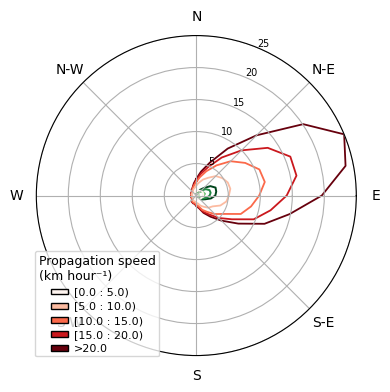

In [10]:
from windrose import WindroseAxes
import matplotlib.cm as cm
trx_dir_all = trx_all.dropna(subset=['bearing', 'speed'])
northsea_bound = trx_dir_all[(trx_dir_all['lon_vor'] >= -4) & (trx_dir_all['lon_vor'] <= 10) & 
                      (trx_dir_all['lat_vor'] >= 50) & (trx_dir_all['lat_vor'] <= 60)]
trx_dir_north = northsea_bound.dropna(subset=['bearing', 'speed'])

fig = plt.figure(figsize=(4., 4.))
ax = WindroseAxes.from_ax(fig=fig)

#ax.contourf(trx_dir_all['bearing'].values, trx_dir_all['speed'].values, bins=np.arange(0, 40, 10), cmap=plt.cm.Blues, alpha=0.9, normed=True)
ax.contour(trx_dir_all['bearing'].values, trx_dir_all['speed'].values, bins=np.arange(0, 22, 5), cmap=cm.Reds, 
           lw=1.3, alpha=1, nsector=32) #normed=True, 
ax.contour(trx_dir_north['bearing'].values, trx_dir_north['speed'].values, bins=np.arange(0, 22, 5), cmap=cm.Greens, 
           lw=1.4, alpha=1, nsector=32) #normed=True,


#ax.contourf(trx_dir_north['bearing'].values, trx_dir_north['speed'].values, bins=np.arange(0, 40, 10), cmap=plt.cm.Reds, alpha=0.4, normed=True)

#ax.set_rgrids([], labels=None)
ax.set_yticklabels([5, 10, 15, 20, 25], fontsize=7)
ax.set_legend(title="Propagation speed\n(km hour⁻¹)", title_fontsize=9, loc="lower left", fontsize=6)
plt.show()

## Closure Storm (Filter Storm with Closure Date Window)

### Type of Closure Storm

In [289]:
closdata = pd.read_csv('northsea/closure_date_window.csv')
closdata['Closure Dates'] = closdata['Closure Dates'].astype(str)
closdata['Window -2'] = closdata['Window -2'].astype(str)
closdata['Window +2'] = closdata['Window +2'].astype(str)
closdata['Closure Dates'] = pd.to_datetime(closdata['Closure Dates'], format='%d/%m/%Y')
closdata['Window -2'] = pd.to_datetime(closdata['Window -2'], format='%d/%m/%Y')
closdata['Window +2'] = pd.to_datetime(closdata['Window +2'], format='%d/%m/%Y', errors='coerce')

In [290]:
date_columns = ['Closure Dates', 'Window -2', 'Window +2']
for col in date_columns:
    closdata[col] = pd.to_datetime(closdata[col])

trx_all['date'] = pd.to_datetime(trx_all['date'])

northsea_bound = trx_all[(trx_all['lon_vor'] >= -12) & (trx_all['lon_vor'] <= 12) & 
                         (trx_all['lat_vor'] >= 45) & (trx_all['lat_vor'] <= 65)]


filtered_trx = pd.DataFrame(columns=['date', 'season', 'closure_ID', 'closure_date', 'closure_type', 'uniq_id'])

for _, row in closdata.iterrows():
    closure_id = row['FD Closure Number']
    closure_date = row['Closure Dates']
    closure_type = row['Type']
    start_date = row['Window -2']
    end_date = row['Window +2']

    valid_ids = northsea_bound[(northsea_bound['date'] >= start_date) & 
                               (northsea_bound['date'] <= end_date)]['uniq_id'].drop_duplicates()
    
    trx_bound = trx_all[trx_all['uniq_id'].isin(valid_ids)]
    filtered_window_trx = trx_bound[['date', 'season', 'uniq_id']].copy()
    
    filtered_window_trx['closure_ID'] = closure_id
    filtered_window_trx['closure_date'] = closure_date
    filtered_window_trx['closure_type'] = closure_type
    filtered_trx = pd.concat([filtered_trx, filtered_window_trx], ignore_index=True)

filtered_trx.reset_index(drop=True, inplace=True)
filtered_trx

/tmp/ipykernel_555/653494922.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  filtered_trx = pd.concat([filtered_trx, filtered_window_trx], ignore_index=True)


,date,season,closure_ID,closure_date,closure_type,uniq_id
0,1983-01-23 07:00:00,1982-1983,1,1983-02-01,Tidal,"(17712, 1982-1983)"
1,1983-01-23 08:00:00,1982-1983,1,1983-02-01,Tidal,"(17712, 1982-1983)"
2,1983-01-23 09:00:00,1982-1983,1,1983-02-01,Tidal,"(17712, 1982-1983)"
3,1983-01-23 10:00:00,1982-1983,1,1983-02-01,Tidal,"(17712, 1982-1983)"
4,1983-01-23 11:00:00,1982-1983,1,1983-02-01,Tidal,"(17712, 1982-1983)"
...,...,...,...,...,...,...
24545,2022-02-22 16:00:00,2021-2022,206,2022-02-21,Tidal,"(25288, 2021-2022)"
24546,2022-02-22 17:00:00,2021-2022,206,2022-02-21,Tidal,"(25288, 2021-2022)"
24547,2022-02-22 18:00:00,2021-2022,206,2022-02-21,Tidal,"(25288, 2021-2022)"
24548,2022-02-22 19:00:00,2021-2022,206,2022-02-21,Tidal,"(25288, 2021-2022)"


In [292]:
print('all storm:', filtered_trx['uniq_id'].nunique())
print('all storm season:', filtered_trx['season'].nunique())
print('closure type:', filtered_trx['closure_type'].nunique())
print('closure id:', filtered_trx['closure_ID'].nunique())
print('all storm:', filtered_trx.drop_duplicates(subset=['uniq_id', 'closure_ID']).shape[0])


all storm: 93
all storm season: 30
closure type: 3
closure id: 125
all storm: 200


In [293]:
unique_identifiers = filtered_trx['uniq_id'].unique()
storm_closure = trx_all[trx_all['uniq_id'].isin(unique_identifiers)]
storm_closure['duration'] = pd.to_timedelta(storm_closure['duration'])
storm_closure['duration_hours'] = storm_closure['duration'].dt.total_seconds() / 3600
storm_closure.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,start_time,median_time,name,season,duration,distance,speed,bearing,uniq_id,category
1278,1278,1983-01-23 07:00:00,-101.572998,49.398632,1.690920,255.2196,44.93248,1007.834,260.7188,43.70022,...,1983-01-23 07:00:00,NaN,NaN,1982-1983,8 days 19:00:00,43.296328,12.026758,28.361865,"(17712, 1982-1983)",Westerly
1279,1279,1983-01-23 08:00:00,-101.287659,49.740837,1.806277,NaN,NaN,1012.883,251.7188,52.97422,...,1983-01-23 07:00:00,NaN,NaN,1982-1983,8 days 19:00:00,21.353715,5.931588,42.305112,"(17712, 1982-1983)",Westerly
1280,1280,1983-01-23 09:00:00,-101.087677,49.882652,1.894147,NaN,NaN,1012.730,251.7188,52.97422,...,1983-01-23 07:00:00,NaN,NaN,1982-1983,8 days 19:00:00,186.789005,51.885835,167.888273,"(17712, 1982-1983)",Westerly
1281,1281,1983-01-23 10:00:00,-100.560120,48.239216,2.225054,259.7789,47.66829,1010.700,254.5312,43.41919,...,1983-01-23 07:00:00,NaN,NaN,1982-1983,8 days 19:00:00,24.085116,6.690310,39.952441,"(17712, 1982-1983)",Westerly
1282,1282,1983-01-23 11:00:00,-100.351227,48.405067,2.264972,NaN,NaN,1010.796,252.8438,52.41216,...,1983-01-23 07:00:00,NaN,NaN,1982-1983,8 days 19:00:00,25.641530,7.122647,56.336624,"(17712, 1982-1983)",Westerly


In [295]:
noclos_season = ['1983-1984', '1984-1985', '1985-1986', '1987-1988', '1991-1992', '2001-2002', '2003-2004',
                 '2010-2011', '2011-2012', '2014-2015', '2020-2021']

new_rows = [{'season': season} for season in noclos_season]
new_df = pd.DataFrame(new_rows, columns=storm_closure.columns)
storm_closure = pd.concat([storm_closure, new_df], ignore_index=True)
storm_closure

/tmp/ipykernel_555/3042496637.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  storm_closure = pd.concat([storm_closure, new_df], ignore_index=True)


,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,median_time,name,season,duration,distance,speed,bearing,uniq_id,category,duration_hours
0,1278.0,1983-01-23 07:00:00,-101.572998,49.398632,1.690920,255.2196,44.93248,1007.834,260.7188,43.70022,...,NaN,NaN,1982-1983,8 days 19:00:00,43.296328,12.026758,28.361865,"(17712, 1982-1983)",Westerly,211.0
1,1279.0,1983-01-23 08:00:00,-101.287659,49.740837,1.806277,NaN,NaN,1012.883,251.7188,52.97422,...,NaN,NaN,1982-1983,8 days 19:00:00,21.353715,5.931588,42.305112,"(17712, 1982-1983)",Westerly,211.0
2,1280.0,1983-01-23 09:00:00,-101.087677,49.882652,1.894147,NaN,NaN,1012.730,251.7188,52.97422,...,NaN,NaN,1982-1983,8 days 19:00:00,186.789005,51.885835,167.888273,"(17712, 1982-1983)",Westerly,211.0
3,1281.0,1983-01-23 10:00:00,-100.560120,48.239216,2.225054,259.7789,47.66829,1010.700,254.5312,43.41919,...,NaN,NaN,1982-1983,8 days 19:00:00,24.085116,6.690310,39.952441,"(17712, 1982-1983)",Westerly,211.0
4,1282.0,1983-01-23 11:00:00,-100.351227,48.405067,2.264972,NaN,NaN,1010.796,252.8438,52.41216,...,NaN,NaN,1982-1983,8 days 19:00:00,25.641530,7.122647,56.336624,"(17712, 1982-1983)",Westerly,211.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11097,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2003-2004,NaT,NaN,NaN,NaN,NaN,NaN,NaN
11098,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2010-2011,NaT,NaN,NaN,NaN,NaN,NaN,NaN
11099,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2011-2012,NaT,NaN,NaN,NaN,NaN,NaN,NaN
11100,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2014-2015,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [400]:
df_unique = filtered_trx.drop_duplicates(subset=['closure_ID'])
#df_unique['date'] = pd.to_datetime(df_unique['date'])
df_sorted = df_unique.sort_values(by='season')
df_sorted

,date,season,closure_ID,closure_date,closure_type,uniq_id
0,1983-01-23 07:00:00,1982-1983,1,1983-02-01,Tidal,"(17712, 1982-1983)"
440,1987-03-23 22:00:00,1986-1987,3,1987-03-29,Combined,"(27184, 1986-1987)"
634,1988-12-18 10:00:00,1988-1989,4,1988-12-24,Tidal,"(11999, 1988-1989)"
778,1990-02-23 05:00:00,1989-1990,6,1990-02-27,Combined,"(22580, 1989-1990)"
1297,1990-02-23 07:00:00,1989-1990,7,1990-02-28,Tidal,"(22594, 1989-1990)"
...,...,...,...,...,...,...
23927,2021-12-30 22:00:00,2021-2022,203,2022-01-05,Tidal,"(15628, 2021-2022)"
24170,2022-02-05 16:00:00,2021-2022,205,2022-02-04,Tidal,"(22500, 2021-2022)"
23635,2021-10-16 19:00:00,2021-2022,200,2021-10-21,Tidal,"(2505, 2021-2022)"
23749,2021-12-30 22:00:00,2021-2022,202,2022-01-04,Tidal,"(15628, 2021-2022)"


In [480]:
filtered_storm = filtered_trx.drop_duplicates(subset=['closure_ID'])
season_counts = filtered_storm['season'].value_counts().sort_index()
season_counts

season
1982-1983     1
1986-1987     1
1988-1989     1
1989-1990     3
1990-1991     1
1992-1993     2
1993-1994     3
1994-1995     3
1995-1996     3
1996-1997     1
1997-1998     1
1998-1999     1
1999-2000     6
2000-2001    16
2002-2003     1
2004-2005     2
2005-2006     2
2006-2007     8
2007-2008     6
2008-2009     4
2009-2010     5
2012-2013     5
2013-2014    27
2015-2016     1
2016-2017     2
2017-2018     4
2018-2019     2
2019-2020     6
2020-2021     1
2021-2022     6
Name: count, dtype: int64

In [178]:
ids_to_plot = filtered_trx[filtered_trx['closure_type'] == closure_type]['uniq_id']
data_to_plot = storm_closure[storm_closure['uniq_id'].isin(ids_to_plot)]
data_to_plot

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,var_prec,ID,start_time,median_time,name,season,distance,speed,bearing,unique_identifier
1498,143452,1983-01-23 07:00:00,-101.572998,49.398632,1.690920,255.21960,44.93248,1007.8340,260.71880,43.70022,...,4.471160,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,43.296328,12.026758,28.361865,"(17712, 1982-1983)"
1499,143453,1983-01-23 08:00:00,-101.287659,49.740837,1.806277,NaN,NaN,1012.8830,251.71880,52.97422,...,4.597179,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,21.353715,5.931588,42.305112,"(17712, 1982-1983)"
1500,143454,1983-01-23 09:00:00,-101.087677,49.882652,1.894147,NaN,NaN,1012.7300,251.71880,52.97422,...,4.648538,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,186.789005,51.885835,167.888273,"(17712, 1982-1983)"
1501,143455,1983-01-23 10:00:00,-100.560120,48.239216,2.225054,259.77890,47.66829,1010.7000,254.53120,43.41919,...,9.134160,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,24.085116,6.690310,39.952441,"(17712, 1982-1983)"
1502,143456,1983-01-23 11:00:00,-100.351227,48.405067,2.264972,NaN,NaN,1010.7960,252.84380,52.41216,...,7.310028,17712,1983-01-23 07:00:00,NaN,unknown,1982-1983,25.641530,7.122647,56.336624,"(17712, 1982-1983)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78807,170445,2022-02-22 16:00:00,31.521015,58.192413,6.611389,33.05989,60.44871,987.3088,36.56250,53.53628,...,13.955330,25288,2022-02-20 12:00:00,NaN,unknown,2021-2022,37.156104,10.321140,66.558429,"(25288, 2021-2022)"
78808,170446,2022-02-22 17:00:00,32.102772,58.323799,6.273341,33.76484,60.45305,987.6617,37.40625,53.81731,...,12.864090,25288,2022-02-20 12:00:00,NaN,unknown,2021-2022,37.355214,10.376448,63.874143,"(25288, 2021-2022)"
78809,170447,2022-02-22 18:00:00,32.677505,58.470192,5.907757,34.21578,60.42834,988.0972,39.09375,54.37937,...,11.727830,25288,2022-02-20 12:00:00,NaN,unknown,2021-2022,45.324484,12.590134,68.635127,"(25288, 2021-2022)"
78810,170448,2022-02-22 19:00:00,33.403854,58.616383,5.573356,34.90493,60.47358,988.4915,39.65625,54.37937,...,11.013400,25288,2022-02-20 12:00:00,NaN,unknown,2021-2022,54.103218,15.028672,65.585143,"(25288, 2021-2022)"


In [43]:
#unique_storms_clos = filtered_trx.drop_duplicates(subset=['uniq_id','closure_ID','season', 'closure_type'])
#unique_storms_clos.to_excel("storm_closure_fin_updated.xlsx")

### Statistics and Map

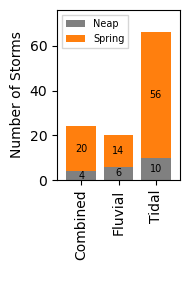

In [45]:
merged_data = filtered_trx.drop_duplicates(subset=['uniq_id', 'closure_type'])
tide_counts = merged_data.groupby(['closure_type', 'Tide']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(2., 3.))
color_mapping = {
    'Spring': 'tab:orange',
    'Neap': 'grey'}

colors = [color_mapping.get(col, 'tab:gray') for col in tide_counts.columns]
tide_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)
#ax.set_title('Closure Storm and Tide')
ax.set_ylabel('Number of Storms')
ax.set_xlabel(' ')
ax.set_ylim(0, max(tide_counts.sum(axis=1)) + 10)
plt.legend(fancybox=False, fontsize=7)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

plt.tight_layout()
plt.show()

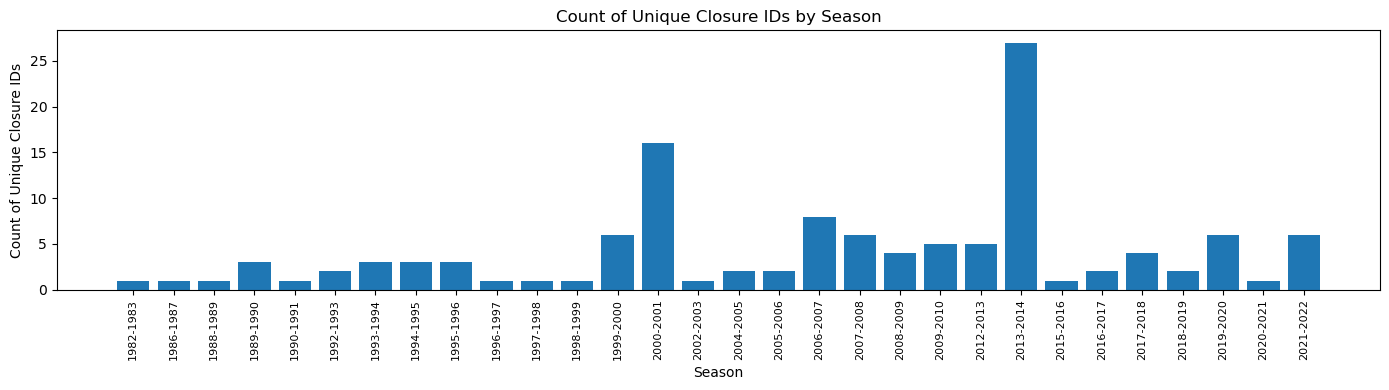

In [428]:
df_unique = filtered_trx.drop_duplicates(subset=['closure_ID'])
closure_count_per_season = df_unique.groupby('season')['closure_ID'].count().reset_index()
closure_count_per_season = closure_count_per_season.sort_values(by='season')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(closure_count_per_season['season'], closure_count_per_season['closure_ID'])
ax.set_xlabel('Season')
ax.set_ylabel('Count of Unique Closure IDs')
ax.set_title('Count of Unique Closure IDs by Season')
plt.xticks(rotation=90, fontweight='ultralight', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
sta_month = storm_closure['start_time'].dropna().unique()
sta_month = pd.to_datetime(sta_month)
sta_months = pd.Series([date.month for date in sta_month])
sta_counts = sta_months.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6., 3.))
months = range(1, 13)
bar_width = 0.35
sta_positions = [x - bar_width/2 for x in months]

bars = ax.bar(months, sta_counts.reindex(months, fill_value=0), width=bar_width, label='Start Time', color='tab:blue')

ax.set_title('Storm frequency (1982-2022) by month')
ax.set_xlabel('Month')
ax.set_ylabel('n of storm')
ax.set_ylim(0, 35)
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
for bar in bars:
   height = bar.get_height()
   ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3),
   textcoords="offset points", ha='center', va='bottom', size=7)

#ax.legend(loc='upper right')

#plt.grid(True)
plt.tight_layout()
plt.show()

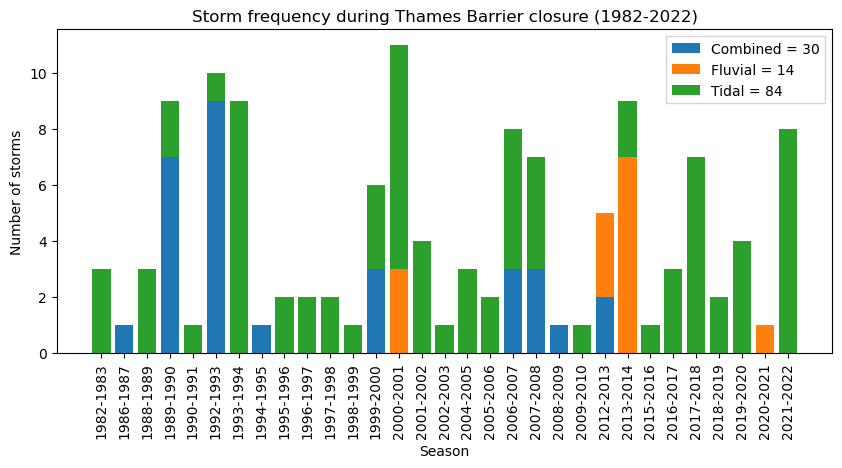

In [64]:
data = {
    'closure_type': ['1982-1983', '1986-1987', '1988-1989', '1989-1990', '1990-1991', '1992-1993', '1993-1994', 
                     '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999', '1999-2000', '2000-2001', 
                     '2001-2002', '2002-2003', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', 
                     '2009-2010', '2012-2013', '2013-2014', '2015-2016', '2016-2017', '2017-2018', '2018-2019', 
                     '2019-2020', '2020-2021', '2021-2022'],
    'Combined': [0, 1, 0, 7, 0, 9, 0, 1, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 3, 3, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0],
    'Fluvial': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 3, 7, 0, 0, 0, 0, 0, 1, 0],
    'Tidal': [3, 0, 3, 2, 1, 1, 9, 0, 2, 2, 2, 1, 3, 8, 4, 1, 3, 2, 5, 4, 0, 1, 0, 2, 1, 3, 7, 2, 4, 0, 8]
}

df = pd.DataFrame(data)
df.set_index('closure_type', inplace=True)

color_mapping = {
    'Fluvial': 'tab:orange',
    'Combined': 'tab:blue',
    'Tidal': 'tab:green'
}

type_totals = df.sum()
legend_labels = [f'{type} = {count}' for type, count in type_totals.items()]

fig, ax = plt.subplots(figsize=(10., 4.2))

bottom = np.zeros(len(df))
for type in df.columns:
    ax.bar(df.index, df[type], label=f'{type} = {type_totals[type]}', color=color_mapping[type], bottom=bottom)
    bottom += df[type].values

plt.title('Storm frequency during Thames Barrier closure (1982-2022)')
plt.xlabel('Season')
plt.ylabel('Number of storms')
plt.xticks(rotation=90)
plt.legend(fancybox=False)
plt.show()

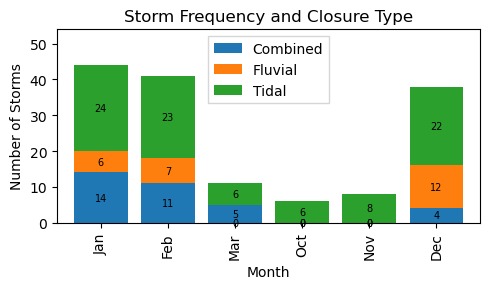

In [194]:
merged_data = pd.merge(filtered_trx[['uniq_id', 'closure_type']], storm_closure, on='uniq_id')
merged_data = merged_data.drop_duplicates(subset=['uniq_id', 'start_time', 'closure_type'])

merged_data['month'] = pd.to_datetime(merged_data['start_time']).dt.month
monthly_counts = merged_data.groupby(['month', 'closure_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(5., 3.))
color_mapping = {
    'Fluvial': 'tab:orange',
    'Combined': 'tab:blue',
    'Tidal': 'tab:green'
}

colors = [color_mapping.get(col, 'tab:gray') for col in monthly_counts.columns]
monthly_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)

ax.set_title('Storm Frequency and Closure Type')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Storms')
ax.set_ylim(0, max(monthly_counts.sum(axis=1)) + 10)
ax.set_xticks(range(6))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Oct', 'Nov', 'Dec'])
plt.legend(fancybox=False)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

plt.tight_layout()
plt.show()


In [240]:
def plot_track_2(data_trx, filtered_trx):  
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180
    n_storm = data_trx['uniq_id'].nunique()

    color_mapping = {
        'Combined': 'tab:blue',
        'Fluvial': 'tab:orange',
        'Tidal': 'tab:green'
    }

    unique_ids = filtered_trx['uniq_id'].unique()
    identifier_colors = {uid: color_mapping[filtered_trx[filtered_trx['uniq_id'] == uid]['closure_type'].values[0]] for uid in unique_ids}


    fig, ax = plt.subplots(figsize=(7., 7.), subplot_kw={'projection': mapcrs})
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    for name, group in data_trx.groupby('uniq_id'):
        points = group[['lon_vor', 'lat_vor']].values
        storm_color = identifier_colors[name]

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            ax.plot(line[:, 0], line[:, 1], color=storm_color, linewidth=0.7, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-12, 45], width=24, height=20, zorder=18, facecolor='none', edgecolor='black', transform=datacrs))
    ax.add_patch(mpatches.Rectangle(xy=[-6, 50], width=15, height=10, zorder=19, facecolor='none', edgecolor='red', transform=datacrs))
                                
    ax.set_title(f"North Sea's Storm within Thames Barrier Closure Date Window (n={n_storm})")

    plt.show()

In [79]:
def plot_track_3(data_trx, filtered_trx):  
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    boundary = [-70, 60, 90, 35]
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180
    n_storm = data_trx['uniq_id'].nunique()

    color_mapping = {
        'Combined': 'tab:blue',
        'Fluvial': 'tab:orange',
        'Tidal': 'tab:green'
    }

    fig, axs = plt.subplots(3, 1, figsize=(7., 10.), subplot_kw={'projection': mapcrs})
    fig.subplots_adjust(hspace=0.25)
    
    closure_types = ['Combined', 'Fluvial', 'Tidal']
    
    for i, closure_type in enumerate(closure_types):
        ax = axs[i]
        ax.set_extent(boundary, crs=datacrs)
        ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        
        ids_to_plot = filtered_trx[filtered_trx['closure_type'] == closure_type]['uniq_id']
        data_to_plot = data_trx[data_trx['uniq_id'].isin(ids_to_plot)]
        
        for name, group in data_to_plot.groupby('uniq_id'):
            points = group[['lon_vor', 'lat_vor']].values
            storm_color = color_mapping[closure_type] 

            for j in range(len(points) - 1):
                line = np.array([points[j], points[j + 1]])
                ax.plot(line[:, 0], line[:, 1], color=storm_color,
                        linewidth=0.7, transform=datacrs)
                
        unique_tracks = len(ids_to_plot.unique())
        #ax.add_patch(mpatches.Rectangle(xy=[-12, 45], width=24, height=20, zorder=18, facecolor='none', edgecolor='black', 
        #                                linewidth=1, transform=datacrs))
        ax.set_title(f"{closure_type} Closure Storm (n={unique_tracks})", fontsize=10, loc='left')

    plt.show()


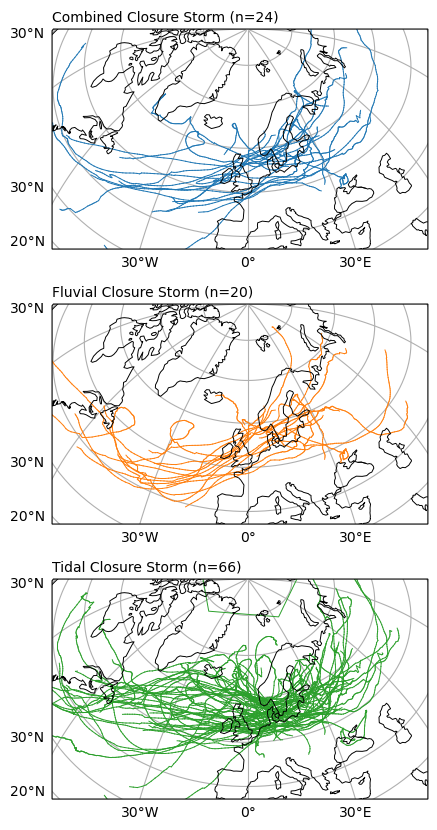

In [80]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_3(storm_closure, filtered_trx)

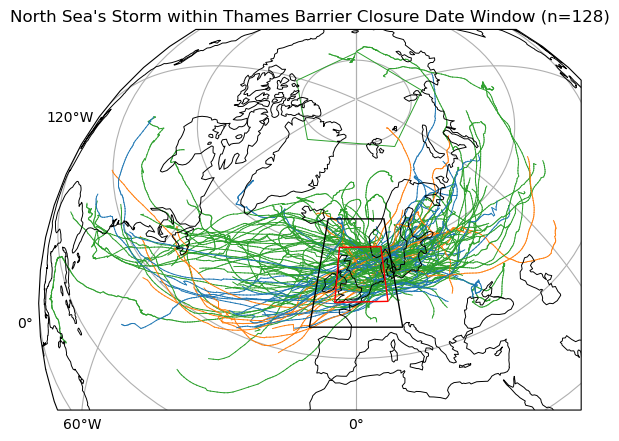

In [241]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_2(storm_closure, filtered_trx)

### Meteorological parameters

In [215]:
def plot_track_var(data_trx, var, filtered_trx, closure_type): 
    var_name = {'vor': (1, 14, 'vorticity (×10⁻⁵ s⁻¹)'),
                'wind': (10, 50, '925-hPa wind speed max (m s⁻¹)'),
                'mslp': (970, 1000, 'mean sea level pressure (hPa)'),
                'prec': (2, 30, 'precipitation (mm)'),
                'speed': (2, 20, 'track propagation speed (km/h)')}
    
    boundary = [-70, 60, 90, 35]
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180
    n_storm = data_trx['uniq_id'].nunique()

    fig, ax = plt.subplots(figsize=(7., 7.), subplot_kw={'projection': mapcrs})
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')
    ax.set_extent(boundary, crs=datacrs)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    cmap = plt.cm.viridis
    norm = plt.Normalize(var_name[var][0], var_name[var][1])

    # Filter data for the current closure type
    ids_to_plot = filtered_trx[filtered_trx['closure_type'] == closure_type]['uniq_id']
    data_to_plot = data_trx[data_trx['uniq_id'].isin(ids_to_plot)]

    # Processing each group
    for name, group in data_to_plot.groupby('uniq_id'):
        # Ensure the 'Speed' data is numeric and handle NaNs
        group[var] = pd.to_numeric(group[f'{var}'], errors='coerce')
        group[var].fillna(group[f'{var}'].mean(), inplace=True)

        points = group[['lon_vor', 'lat_vor']].values
        color_values = norm(group[f'{var}'].values)  # Normalize speed values
        colors = cmap(color_values)  # Convert normalized values to colors

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group[f'{var}'].iloc[i] + group[f'{var}'].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.8, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-12, 45], width=24, height=20, zorder=18, facecolor='none', edgecolor='black', transform=datacrs))
                                
    ax.set_title(f"{closure_type} closure Storm")
    labelin = var_name[var][2]
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                orientation='horizontal', label=labelin)
    plt.show()

In [124]:
def plot_track_var(data_trx, var, filtered_trx): 
    var_name = {'var_vor': (1, 14, 'vorticity (×10⁻⁵ s⁻¹)'),
                'var_wind': (10, 50, '925-hPa max wind speed (m s⁻¹)'),
                'var_mslp': (970, 1000, 'mean sea level pressure (hPa)'),
                'var_prec': (2, 30, 'precipitation (mm)'),
                'speed': (2, 20, 'track propagation speed (km hour⁻¹)')}
    
    boundary = [-70, 60, 90, 35]
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 

    fig, axs = plt.subplots(3, 1, figsize=(7., 10.), subplot_kw={'projection': mapcrs})
    fig.subplots_adjust(hspace=0.45)

    closure_types = ['Combined', 'Fluvial', 'Tidal']
    cmap = plt.cm.winter
    #norm = plt.Normalize(var_name[var][0], var_name[var][1])
    norm = plt.Normalize(5, 50)
    labelin = var_name[var][2]

    for i, closure_type in enumerate(closure_types):
        ax = axs[i]
        ax.set_extent(boundary, crs=datacrs)
        ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        
        # Filter data for the current closure type
        ids_to_plot = filtered_trx[filtered_trx['closure_type'] == closure_type]['uniq_id']
        data_to_plot = data_trx[data_trx['uniq_id'].isin(ids_to_plot)]

        for name, group in data_to_plot.groupby('uniq_id'):
            group[var] = pd.to_numeric(group[f'{var}'], errors='coerce')
            group[var].fillna(group[f'{var}'].mean(), inplace=True)

            points = group[['lon_vor', 'lat_vor']].values
            color_values = norm(group[f'{var}'].values)  # Normalize speed values
            colors = cmap(color_values)  # Convert normalized values to colors

            for i in range(len(points) - 1):
                line = np.array([points[i], points[i + 1]])
                mid_value = norm((group[f'{var}'].iloc[i] + group[f'{var}'].iloc[i + 1]) / 2)
                ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.35, transform=datacrs)

        ax.add_patch(mpatches.Rectangle(xy=[-10, 50], width=20, height=10, zorder=18, facecolor='none', 
                                        edgecolor='red', lw=0.48, transform=datacrs))
                                
        ax.set_title(f"{closure_type} Closure Storm", loc='left')

    fig.subplots_adjust(bottom=0.05, right=0.8, top=0.95, wspace=0.05, hspace=0.25)
    #cax = fig.add_axes([0.842, 0.2, 0.02, 0.55])    
    #plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, pad=0.05, aspect=50,
    #            orientation='vertical', label=labelin)
    cax = fig.add_axes([0.2, 0.001, 0.52, 0.01])    
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, pad=0.05, aspect=50,
                orientation='horizontal', label=labelin)
    plt.show()

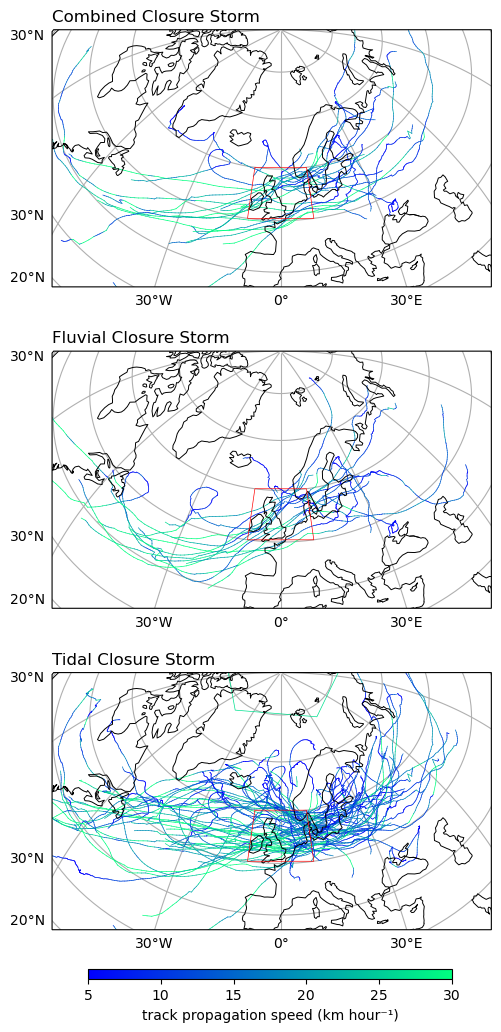

In [113]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_var(storm_closure, 'speed', filtered_trx)

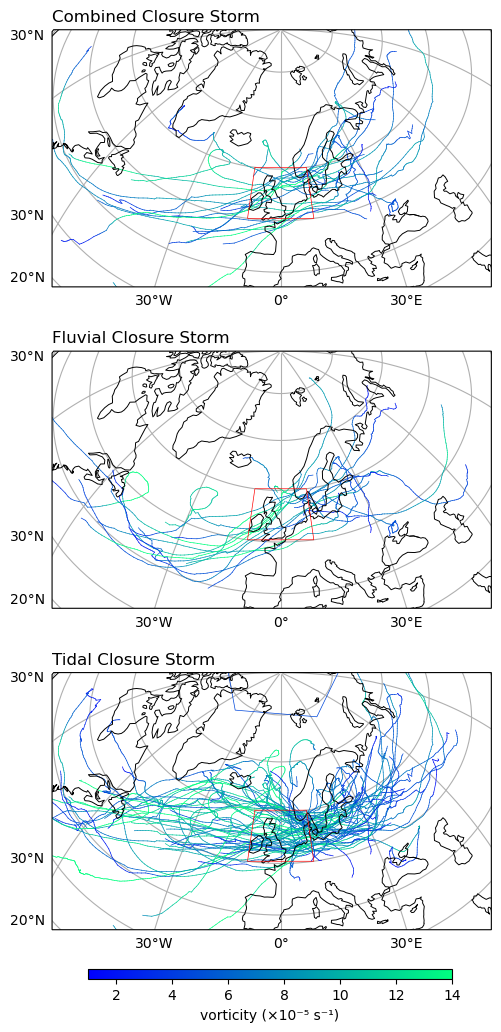

In [117]:
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_var(storm_closure, 'var_vor', filtered_trx)

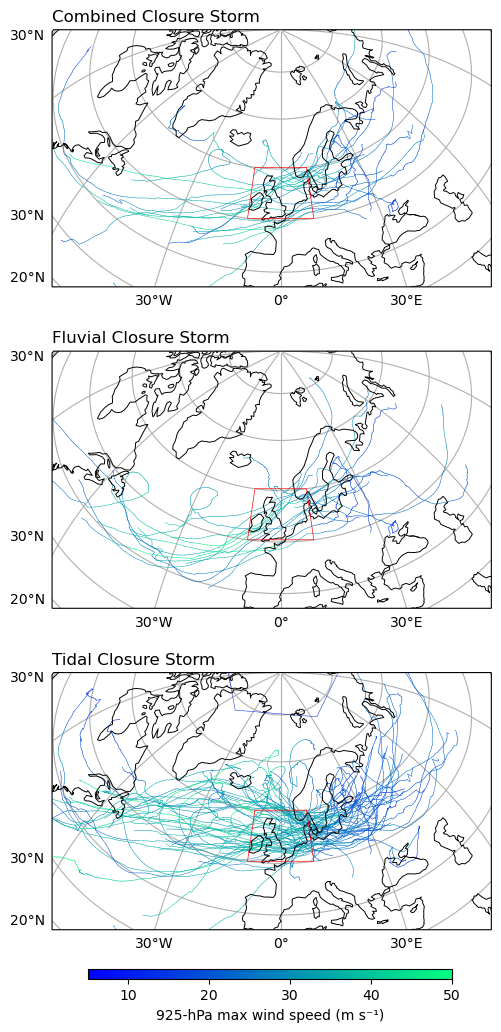

In [125]:
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_var(storm_closure, 'var_wind', filtered_trx)

## Fluvial storm closure

In [296]:
fluv_storm_sel = filtered_trx[filtered_trx['closure_type'] == 'Fluvial']['uniq_id']
fluv_storm = storm_closure[storm_closure['uniq_id'].isin(fluv_storm_sel)]
#fluv_storm
"""
crop_storm = fluv_storm.drop_duplicates(subset=['uniq_id'])
dir_count = crop_storm['category'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(2., 3.))
bars = dir_count.plot(kind='bar', color='tab:blue', ax=ax)
for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height), 
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', size=7)
plt.xlabel(' ')
plt.ylabel('Number of Storms')
plt.show()
"""

'\ncrop_storm = fluv_storm.drop_duplicates(subset=[\'uniq_id\'])\ndir_count = crop_storm[\'category\'].value_counts().sort_index()\n\nfig, ax = plt.subplots(figsize=(2., 3.))\nbars = dir_count.plot(kind=\'bar\', color=\'tab:blue\', ax=ax)\nfor bar in bars.patches:\n    height = bar.get_height()\n    ax.annotate(f\'{height}\', xy=(bar.get_x() + bar.get_width() / 2, height), \n                xytext=(0, 3), textcoords="offset points", ha=\'center\', va=\'bottom\', size=7)\nplt.xlabel(\' \')\nplt.ylabel(\'Number of Storms\')\nplt.show()\n'

In [70]:
storm_fluv_dist = fluv_storm.groupby('uniq_id')['distance'].sum()
storm_fluv_dist.values.mean()

5580.8448786360905

In [98]:
fluv_uniq_id = fluv_storm['uniq_id'].unique()
mean_dur_fluv = []

for id in fluv_uniq_id:
    starts = fluv_storm[fluv_storm['uniq_id']==id]['date'].min()
    ends = fluv_storm[fluv_storm['uniq_id']==id]['date'].max()
    dur_storm = ends - starts
    mean_dur_fluv.append(dur_storm)

np.mean(mean_dur_fluv)

Timedelta('4 days 10:15:00')

In [14]:
ssi_fluv = (fluv_storm['var_vor'] - fluv_storm['var_vor'].mean) / vor_std.values
plt.plot(ssi)

## Combined storm closure

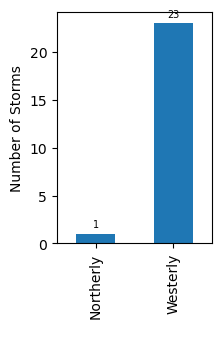

In [297]:
com_storm_sel = filtered_trx[filtered_trx['closure_type'] == 'Combined']['uniq_id']
com_storm = storm_closure[storm_closure['uniq_id'].isin(com_storm_sel)]
crop_storm = com_storm.drop_duplicates(subset=['uniq_id'])
dir_count = crop_storm['category'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(2., 3.))
bars = dir_count.plot(kind='bar', color='tab:blue', ax=ax)
for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height), 
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', size=7)
plt.xlabel(' ')
plt.ylabel('Number of Storms')
plt.show()

In [71]:
storm_com_dist = com_storm.groupby('uniq_id')['distance'].sum()
storm_com_dist.values.mean()

5919.085730842457

In [99]:
com_uniq_id = com_storm['uniq_id'].unique()
mean_dur_com = []

for id in com_uniq_id:
    starts = com_storm[com_storm['uniq_id']==id]['date'].min()
    ends = com_storm[com_storm['uniq_id']==id]['date'].max()
    dur_storm = ends - starts
    mean_dur_com.append(dur_storm)

np.mean(mean_dur_com)

Timedelta('4 days 12:12:30')

## Tidal storm closure

In [298]:
tidal_storm_sel = filtered_trx[filtered_trx['closure_type'] == 'Tidal']['uniq_id']
tidal_storm = storm_closure[storm_closure['uniq_id'].isin(tidal_storm_sel)]

In [299]:
tid_noclos_season = ['1983-1984', '1984-1985', '1985-1986', '1986-1987', '1987-1988', '1991-1992', 
                     '1992-1993', '1994-1995', '2001-2002', '2003-2004', '2008-2009', 
                 '2010-2011', '2011-2012', '2012-2013', '2014-2015', '2020-2021']

new_rows = [{'season': season} for season in tid_noclos_season]
new_tidal_storm = pd.DataFrame(new_rows, columns=tidal_storm.columns)
tidal_storm = pd.concat([tidal_storm, new_tidal_storm], ignore_index=True)
tidal_storm = tidal_storm.sort_values(by='season')
tidal_storm

/tmp/ipykernel_555/2120197638.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tidal_storm = pd.concat([tidal_storm, new_tidal_storm], ignore_index=True)


,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,median_time,name,season,duration,distance,speed,bearing,uniq_id,category,duration_hours
0,1278.0,1983-01-23 07:00:00,-101.572998,49.398632,1.690920,255.219600,44.93248,1007.8340,260.71880,43.70022,...,NaN,NaN,1982-1983,8 days 19:00:00,43.296328,12.026758,28.361865,"(17712, 1982-1983)",Westerly,211.0
300,1712.0,1983-02-01 19:00:00,42.062092,56.817303,5.300707,38.550890,59.17110,991.9227,47.53125,55.50349,...,NaN,NaN,1982-1983,3 days 19:00:00,54.354925,15.098590,108.651650,"(18764, 1982-1983)",Westerly,91.0
299,1711.0,1983-02-01 18:00:00,41.281956,56.912235,5.363314,38.568860,58.61089,991.6319,48.37500,54.09834,...,NaN,NaN,1982-1983,3 days 19:00:00,48.742287,13.539524,102.199133,"(18764, 1982-1983)",Westerly,91.0
298,1710.0,1983-02-01 17:00:00,40.614597,56.911766,5.473014,38.040930,58.67883,991.5203,47.81250,54.09834,...,NaN,NaN,1982-1983,3 days 19:00:00,40.652416,11.292338,89.646823,"(18764, 1982-1983)",Westerly,91.0
297,1709.0,1983-02-01 16:00:00,40.043671,56.889469,5.589205,37.884990,58.56681,991.4426,46.96875,54.09834,...,NaN,NaN,1982-1983,3 days 19:00:00,34.877248,9.688124,85.678500,"(18764, 1982-1983)",Westerly,91.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7947,768.0,2022-01-06 04:00:00,17.842072,54.091476,4.684944,NaN,NaN,999.9304,19.96875,58.59482,...,NaN,NaN,2021-2022,7 days 09:00:00,17.577751,4.882709,117.104474,"(15628, 2021-2022)",Northerly,177.0
7948,769.0,2022-01-06 05:00:00,18.080797,54.019287,4.583052,NaN,NaN,1000.6010,20.81250,58.87585,...,NaN,NaN,2021-2022,7 days 09:00:00,19.070171,5.297270,136.201472,"(15628, 2021-2022)",Northerly,177.0
7949,770.0,2022-01-06 06:00:00,18.281572,53.895454,4.350677,NaN,NaN,1001.5750,21.37500,58.59482,...,NaN,NaN,2021-2022,7 days 09:00:00,26.935681,7.482134,164.101713,"(15628, 2021-2022)",Northerly,177.0
7940,761.0,2022-01-05 21:00:00,13.732566,53.843258,5.938726,NaN,NaN,998.2402,15.46875,51.85009,...,NaN,NaN,2021-2022,7 days 09:00:00,123.153785,34.209385,50.775820,"(15628, 2021-2022)",Northerly,177.0


In [300]:
tidal_storm['season'] = tidal_storm['season'].str.strip()
season_tid = tidal_storm.drop_duplicates(subset=['season'])
season_tid = season_tid['season'].values

In [302]:
print(len(season_tid))
range_tid = np.arange(0,40,1)
print(len(range_tid))

40
40


[0.65033306 0.65857168 0.6668103  0.67504891 0.68328753 0.69152615
 0.69976477 0.70800339 0.71624201 0.72448062 0.73271924 0.74095786
 0.74919648 0.7574351  0.76567371 0.77391233 0.78215095 0.79038957
 0.79862819 0.80686681 0.81510542 0.82334404 0.83158266 0.83982128
 0.8480599  0.85629852 0.86453713 0.87277575 0.88101437 0.88925299
 0.89749161 0.90573022 0.91396884 0.92220746 0.93044608 0.9386847
 0.94692332 0.95516193 0.96340055 0.97163917]


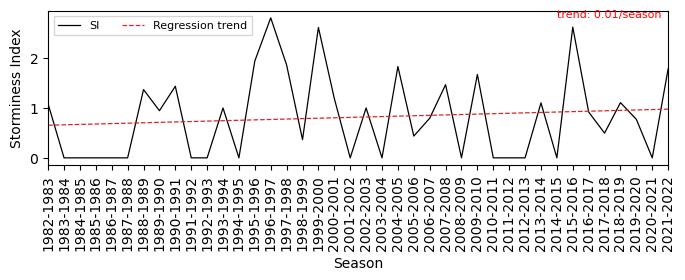

In [303]:
tid_vor_perc = tidal_storm.groupby('season')['var_vor'].apply(lambda x: x.quantile(0.9))
tid_vor_mean = tidal_storm['var_vor'].mean()
tid_vor_std = tidal_storm['var_vor'].std()
tid_ssi = (tid_vor_perc.values - tid_vor_mean) / tid_vor_std
tid_ssi = np.nan_to_num(tid_ssi, nan=0)
slope_tid, intercept_tid, r_value_tid, p_value_tid, std_err_tid = linregress(range_tid, tid_ssi)
Y_tid= intercept_tid + slope_tid * range_tid

fig, ax = plt.subplots(figsize=(8., 2.))
#ax.set_ylim(-2.5,2.5)
print(Y_tid)
ax.plot(season_tid, tid_ssi, color='black', linewidth=0.9, label='SI')
ax.plot(range_tid, Y_tid, color='tab:red', linewidth=0.9, linestyle='--', label='Regression trend')
ax.legend(fontsize=8, fancybox=False, ncol=2, loc='upper left')
ax.set_ylabel('Storminess Index')
ax.set_xlim(0,39)
ax.set_xlabel('Season')
slope_text = f'trend: {slope_tid:.2f}/season'
plt.text(32, 2.8, slope_text, fontsize=8, color='red')
plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
plt.show()

In [69]:
storm_tid_dist = tidal_storm.groupby('uniq_id')['distance'].sum()
storm_tid_dist.values.mean()

6251.069997010763

In [97]:
tid_uniq_id = tidal_storm['uniq_id'].unique()
mean_dur_tid = []

for id in tid_uniq_id:
    starts = tidal_storm[tidal_storm['uniq_id']==id]['date'].min()
    ends = tidal_storm[tidal_storm['uniq_id']==id]['date'].max()
    dur_storm = ends - starts
    mean_dur_tid.append(dur_storm)

np.mean(mean_dur_tid)

Timedelta('5 days 06:34:32.727272727')

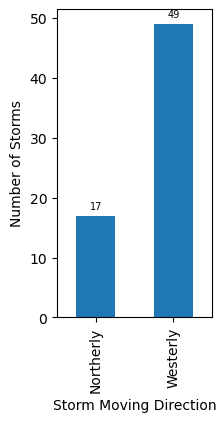

In [40]:
crop_storm = tidal_storm.drop_duplicates(subset=['uniq_id'])
dir_count = crop_storm['category'].value_counts().sort_index()

# Plot the results
fig, ax = plt.subplots(figsize=(2, 4))
bars = dir_count.plot(kind='bar', color='tab:blue', ax=ax)

# Annotate the bars with the height values
for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height), 
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', size=7)

# Add labels and grid
plt.xlabel('Storm Moving Direction')
plt.ylabel('Number of Storms')

# Display the plot
plt.show()


/tmp/ipykernel_554/1958175043.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data['month'] = pd.to_datetime(merged_data['start_time']).dt.month


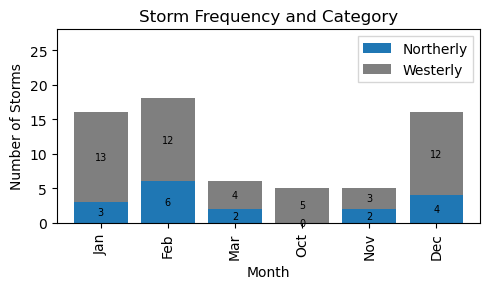

In [17]:
merged_data = tidal_storm.drop_duplicates(subset=['uniq_id'])
merged_data['month'] = pd.to_datetime(merged_data['start_time']).dt.month
monthly_counts = merged_data.groupby(['month', 'category']).size().unstack(fill_value=0)

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(5., 3.))
color_mapping = {
    'Northerly': 'tab:blue',
    'Easterly': 'orange'
}

# Apply color mapping
colors = [color_mapping.get(col, 'tab:gray') for col in monthly_counts.columns]
monthly_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)

# Set the title and labels
ax.set_title('Storm Frequency and Category')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Storms')
ax.set_ylim(0, max(monthly_counts.sum(axis=1)) + 10)
ax.set_xticks(range(6))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Oct', 'Nov', 'Dec'])
plt.legend(fancybox=False)

# Add annotations
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

plt.tight_layout()
plt.show()


In [63]:
def plot_track_tidal(data_trx):
    # Define the coordinate reference systems
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)

    # Normalize longitude to be between -180 and 180
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180

    # Count the number of unique storms
    n_storm = data_trx['uniq_id'].nunique()

   # Define color mapping for each category
    color_mapping = {
        'Northerly': 'tab:blue',
        'Westerly': 'orange',
        'Unknown': 'tab:gray'  # Default color for missing categories
    }

    # Fill missing categories with 'Unknown'
    data_trx['category'] = data_trx['category'].fillna('Unknown')

    # Create the plot
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': mapcrs})
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')

    # Add gridlines with labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    # Plot each storm track
    for name, group in data_trx.groupby('uniq_id'):
        points = group[['lon_vor', 'lat_vor']].values
        storm_color = color_mapping[group['category'].iloc[0]]  # Get the color for this storm based on the category

        # Plot lines between consecutive points
        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            ax.plot(line[:, 0], line[:, 1], color=storm_color, linewidth=0.7, transform=datacrs)

    # Add a rectangle patch for a specific area (North Sea's Storm within Thames Barrier Closure Date Window)
    ax.add_patch(mpatches.Rectangle(xy=[-10, 50], width=20, height=10, zorder=18, facecolor='none', edgecolor='black', transform=datacrs))
    #ax.legend()
    # ax.set_title(f"North Sea's Storm within Thames Barrier Closure Date Window (n={n_storm})")

    plt.show()


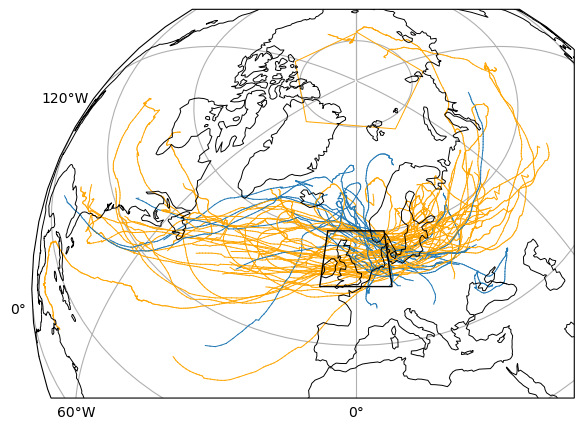

In [64]:
plot_track_tidal(tidal_storm)

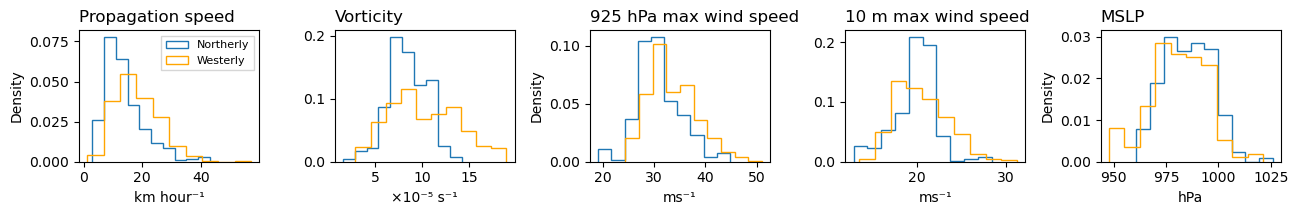

In [34]:
cat_types = ['Northerly', 'Westerly']
colors = ['tab:blue', 'orange']
fig, axs = plt.subplots(1, 5, figsize=(13., 2.25))

for i, cat in enumerate(cat_types):
    ids_type = tidal_storm[tidal_storm['category'] == cat]
    northsea_bound = ids_type[(ids_type['lon_vor'] >= -10) & (ids_type['lon_vor'] <= 10) & 
                                       (ids_type['lat_vor'] >= 50) & (ids_type['lat_vor'] <= 60)]
    
    axs[1].hist(northsea_bound['var_vor'], density=True, histtype='step', color=colors[i], label=cat)
    axs[1].set_title('Vorticity', loc='left')
    axs[1].set_xlabel('×10⁻⁵ s⁻¹')
    axs[2].hist(northsea_bound['var_wind'], density=True, histtype='step', color=colors[i], label=cat)
    axs[2].set_title('925 hPa max wind speed', loc='left')
    axs[2].set_ylabel('Density')
    axs[2].set_xlabel('ms⁻¹')
    axs[4].hist(northsea_bound['var_mslp'], density=True, histtype='step', color=colors[i], label=cat)
    axs[4].set_title('MSLP', loc='left')
    axs[4].set_xlabel('hPa')
    axs[4].set_ylabel('Density')
    axs[3].hist(northsea_bound['var_prec'], density=True, histtype='step', color=colors[i], label=cat)
    axs[3].set_title('10 m max wind speed', loc='left')
    axs[3].set_xlabel('ms⁻¹')
    axs[0].hist(northsea_bound['speed'], density=True, histtype='step', color=colors[i], label=cat)
    axs[0].set_title('Propagation speed', loc='left')
    axs[0].set_xlabel('km hour⁻¹')
    axs[0].set_ylabel('Density')
    axs[0].legend(fancybox=False, framealpha=None, loc='upper right', fontsize=8)    
""""
    northsea_bound['var_vor'].hist(ax=axs[i, 0], density=True)
    axs[i, 0].set_xlim(0,18)
    axs[i, 0].set_ylim(0,0.12)
    axs[i, 0].set_title('Vorticity (×10⁻⁵ s⁻¹)')
    northsea_bound['var_wind'].hist(ax=axs[i, 1], density=True)
    axs[i, 1].set_xlim(20,60)
    axs[i, 1].set_ylim(0,0.12)
    axs[i, 1].set_title('Max Wind Speed (m/s)')
    northsea_bound['var_mslp'].hist(ax=axs[i, 2], density=True)
    axs[i, 2].set_xlim(935,1025)
    axs[i, 2].set_ylim(0,0.027)
    axs[i, 2].set_title('MSLP (hPa)')
    northsea_bound['var_prec'].hist(ax=axs[i, 3], density=True)
    axs[i, 3].set_xlim(12,32)
    axs[i, 3].set_ylim(0,0.16)
    axs[i, 3].set_title('Precipitation (mm)')
    northsea_bound['speed'].hist(ax=axs[i, 4], density=True)
    axs[i, 4].set_xlim(0,55)
    axs[i, 4].set_ylim(0,0.07)
    axs[i, 4].set_title('Propagation speed (km/h)')
    # Add title to the left y-axis
    axs[i, 0].text(-0.2, 0.5, closure_type, va='center', ha='center', rotation='vertical', fontsize=12, fontweight='bold', transform=axs[i, 0].transAxes)
"""
plt.tight_layout()
plt.show()

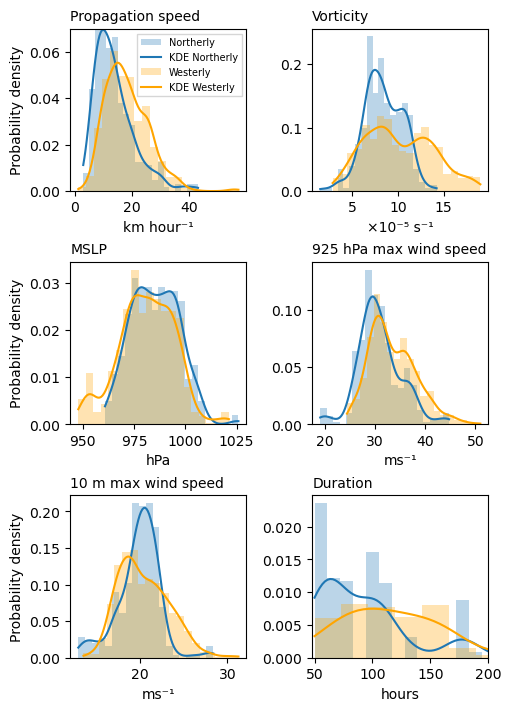

In [28]:
cat_types = ['Northerly', 'Westerly']
colors = ['tab:blue', 'orange']
fig, axs = plt.subplots(3, 2, figsize=(5., 7.), constrained_layout=True)
axs = axs.flatten()

for i, cat in enumerate(cat_types):
    ids_type = tidal_storm[tidal_storm['category'] == cat]
    northsea_bound = ids_type[(ids_type['lon_vor'] >= -10) & (ids_type['lon_vor'] <= 10) & 
                                       (ids_type['lat_vor'] >= 50) & (ids_type['lat_vor'] <= 60)]
    
    kde_speed = gaussian_kde(northsea_bound['speed'])
    x_grid_speed = np.linspace(min(northsea_bound['speed']), max(northsea_bound['speed']), 100)
    kde_val_speed = kde_speed(x_grid_speed)
    mean_speed = np.sum(x_grid_speed * kde_val_speed) * (x_grid_speed[1] - x_grid_speed[0])
    var_speed = np.sum((x_grid_speed - mean_speed)**2 * kde_val_speed) * (x_grid_speed[1] - x_grid_speed[0])
    std_speed = np.sqrt(var_speed)

    kde_vor = gaussian_kde(northsea_bound['var_vor'])
    x_grid_vor = np.linspace(min(northsea_bound['var_vor']), max(northsea_bound['var_vor']), 100)
    kde_val_vor = kde_vor(x_grid_vor)
    mean_vor = np.sum(x_grid_vor * kde_val_vor) * (x_grid_vor[1] - x_grid_vor[0])
    var_vor = np.sum((x_grid_vor - mean_vor)**2 * kde_val_vor) * (x_grid_vor[1] - x_grid_vor[0])
    std_vor = np.sqrt(var_vor)
    
    kde_mslp = gaussian_kde(northsea_bound['var_mslp'])
    x_grid_mslp = np.linspace(min(northsea_bound['var_mslp']), max(northsea_bound['var_mslp']), 100)
    kde_val_mslp = kde_mslp(x_grid_mslp)
    mean_mslp = np.sum(x_grid_mslp * kde_val_mslp) * (x_grid_mslp[1] - x_grid_mslp[0])
    var_mslp = np.sum((x_grid_mslp - mean_mslp)**2 * kde_val_mslp) * (x_grid_mslp[1] - x_grid_mslp[0])
    std_mslp = np.sqrt(var_mslp)

    kde_wind = gaussian_kde(northsea_bound['var_wind'])
    x_grid_wind = np.linspace(min(northsea_bound['var_wind']), max(northsea_bound['var_wind']), 100)
    kde_val_wind = kde_wind(x_grid_wind)
    mean_wind = np.sum(x_grid_wind * kde_val_wind) * (x_grid_wind[1] - x_grid_wind[0])
    var_wind = np.sum((x_grid_wind - mean_wind)**2 * kde_val_wind) * (x_grid_wind[1] - x_grid_wind[0])
    std_wind = np.sqrt(var_wind)

    kde_prec = gaussian_kde(northsea_bound['var_prec'])
    x_grid_prec = np.linspace(min(northsea_bound['var_prec']), max(northsea_bound['var_prec']), 100)
    kde_val_prec = kde_prec(x_grid_prec)
    mean_prec = np.sum(x_grid_prec * kde_val_prec) * (x_grid_prec[1] - x_grid_prec[0])
    var_prec = np.sum((x_grid_prec - mean_prec)**2 * kde_val_prec) * (x_grid_prec[1] - x_grid_prec[0])
    std_prec = np.sqrt(var_prec)

    kde_dur = gaussian_kde(northsea_bound['duration_hours'])
    x_grid_dur = np.linspace(min(northsea_bound['duration_hours']), max(northsea_bound['duration_hours']), 100)
    kde_val_dur = kde_dur(x_grid_dur)
    mean_dur = np.sum(x_grid_dur * kde_val_dur) * (x_grid_dur[1] - x_grid_dur[0])
    var_dur = np.sum((x_grid_dur - mean_dur)**2 * kde_val_dur) * (x_grid_dur[1] - x_grid_dur[0])
    std_dur = np.sqrt(var_dur)

    axs[0].hist(northsea_bound['speed'], bins=20, density=True, alpha=0.3, color=colors[i], label=cat)
    axs[0].plot(x_grid_speed, kde_val_speed, label=f'KDE {cat}', color=colors[i], linewidth=1.5)
    #axs[0].set_title(f'μ= {mean_speed:.2f}, σ= {std_speed:.2f}, σ²= {var_speed:.2f}', fontsize=10, loc='left')
    axs[0].set_title('Propagation speed', loc='left', fontsize=10)
    axs[0].set_ylim(0,0.07)
    axs[0].set_xlabel('km hour⁻¹')
    axs[0].set_ylabel('Probability density')
    axs[0].legend(fancybox=False, framealpha=None, loc='upper right', fontsize=7, ncols=1)
    axs[1].hist(northsea_bound['var_vor'], bins=20, density=True, alpha=0.3, color=colors[i], label=cat)
    axs[1].plot(x_grid_vor, kde_val_vor, label=f'KDE {cat}', color=colors[i], linewidth=1.5)
    #axs[1].set_title(f'{closure_type} μ= {mean_vor:.2f}, σ= {std_vor:.2f}, σ²= {var_vor:.2f}', fontsize=10, loc='left')
    axs[1].set_title('Vorticity', loc='left', fontsize=10)
    axs[1].set_xlabel('×10⁻⁵ s⁻¹')
    axs[2].set_ylabel('Probability density')
    axs[2].hist(northsea_bound['var_mslp'], bins=20, density=True, alpha=0.3, color=colors[i], label=cat)
    axs[2].plot(x_grid_mslp, kde_val_mslp, label=f'KDE {cat}', color=colors[i], linewidth=1.5)
    axs[2].set_title('MSLP', loc='left', fontsize=10)
    axs[2].set_xlabel('hPa')
    axs[3].hist(northsea_bound['var_wind'], bins=20, density=True, alpha=0.3, color=colors[i], label=cat)
    axs[3].plot(x_grid_wind, kde_val_wind, label=f'KDE {cat}', color=colors[i], linewidth=1.5)
    axs[3].set_title('925 hPa max wind speed', loc='left', fontsize=10)
    axs[3].set_xlabel('ms⁻¹')
    axs[4].hist(northsea_bound['var_prec'], bins=20, density=True, alpha=0.3, color=colors[i], label=cat)
    axs[4].plot(x_grid_prec, kde_val_prec, label=f'KDE {cat}', color=colors[i], linewidth=1.5)
    axs[4].set_title('10 m max wind speed', loc='left', fontsize=10)
    axs[4].set_xlabel('ms⁻¹')
    axs[4].set_ylabel('Probability density')
    axs[5].hist(northsea_bound['duration_hours'], bins=20, density=True, alpha=0.3, color=colors[i], label=cat)
    axs[5].plot(x_grid_dur, kde_val_dur, label=f'KDE {cat}', color=colors[i], linewidth=1.5)
    axs[5].set_title('Duration', loc='left', fontsize=10)
    axs[5].set_xlim(48,200)
    axs[5].set_xlabel('hours')
    
#plt.tight_layout()
plt.show()

In [66]:
tidal_storm_uniq = tidal_storm.drop_duplicates(subset=['uniq_id'])
tidal_storm_uniq.to_excel("storm_tidal_update.xlsx")

## Back to All Closure Storm

### Meteorological

In [15]:
northsea_fluv = fluv_storm[(fluv_storm['lon_vor'] >= -10) & (fluv_storm['lon_vor'] <= 10) & 
                                       (fluv_storm['lat_vor'] >= 50) & (fluv_storm['lat_vor'] <= 60)]

print('fluvial: propagation speed =', northsea_fluv['speed'].mean())
print('fluvial: vorticity =', northsea_fluv['var_vor'].mean())
print('fluvial: mslp =', northsea_fluv['var_mslp'].mean())
print('fluvial: 925-hPa wind =', northsea_fluv['var_wind'].mean())
print('fluvial: 10-m wind =', northsea_fluv['var_prec'].mean())

fluvial: propagation speed = 14.405162446485589
fluvial: vorticity = 9.808137695783133
fluvial: mslp = 977.5504442771085
fluvial: 925-hPa wind = 32.735758614457836
fluvial: 10-m wind = 19.716685963855422


In [14]:
northsea_com = com_storm[(com_storm['lon_vor'] >= -10) & (com_storm['lon_vor'] <= 10) & 
                                       (com_storm['lat_vor'] >= 50) & (com_storm['lat_vor'] <= 60)]

print('combined: propagation speed =', northsea_com['speed'].mean())
print('combined: vorticity =', northsea_com['var_vor'].mean())
print('combined: mslp =', northsea_com['var_mslp'].mean())
print('combined: 925-hPa wind =', northsea_com['var_wind'].mean())
print('combined: 10-m wind =', northsea_com['var_prec'].mean())

combined: propagation speed = 17.973682515893667
combined: vorticity = 9.810246873198846
combined: mslp = 979.3344567723343
combined: 925-hPa wind = 33.66664544668588
combined: 10-m wind = 20.00737423631124


In [16]:
northsea_tidal = tidal_storm[(tidal_storm['lon_vor'] >= -10) & (tidal_storm['lon_vor'] <= 10) & 
                                       (tidal_storm['lat_vor'] >= 50) & (tidal_storm['lat_vor'] <= 60)]

print('tidal: propagation speed =', northsea_tidal['speed'].mean())
print('tidal: vorticity =', northsea_tidal['var_vor'].mean())
print('tidal: mslp =', northsea_tidal['var_mslp'].mean())
print('tidal: 925-hPa wind =', northsea_tidal['var_wind'].mean())
print('tidal: 10-m wind =', northsea_tidal['var_prec'].mean())

tidal: propagation speed = 17.00434896714971
tidal: vorticity = 9.639028201688557
tidal: mslp = 982.3795934333958
tidal: 925-hPa wind = 32.739051951219516
tidal: 10-m wind = 20.22831003752345


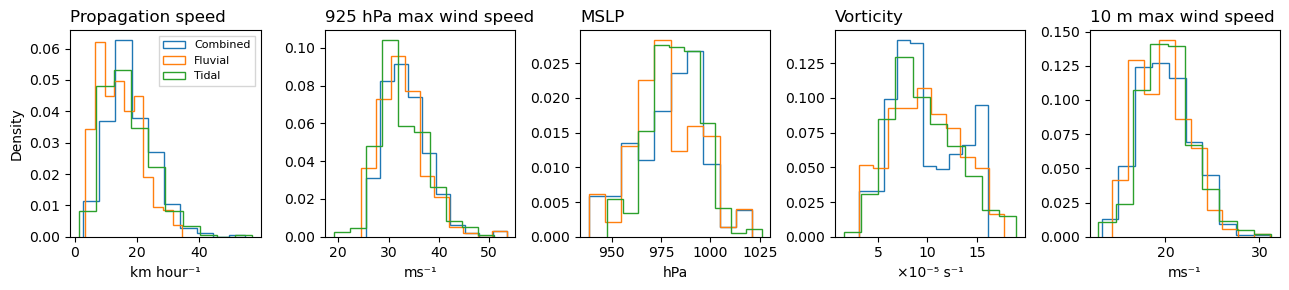

In [25]:
closure_types = ['Combined', 'Fluvial', 'Tidal']
colors = ['tab:blue', 'tab:orange', 'tab:green']
fig, axs = plt.subplots(1, 5, figsize=(13., 3.))

for i, closure_type in enumerate(closure_types):
    ids_type = filtered_trx[filtered_trx['closure_type'] == closure_type]['uniq_id']
    storm_closure_new = storm_closure[storm_closure['uniq_id'].isin(ids_type)]
    northsea_bound = storm_closure_new[(storm_closure_new['lon_vor'] >= -10) & (storm_closure_new['lon_vor'] <= 10) & 
                                       (storm_closure_new['lat_vor'] >= 50) & (storm_closure_new['lat_vor'] <= 60)]
    
    axs[3].hist(northsea_bound['var_vor'], density=True, histtype='step', color=colors[i], label=closure_type)
    axs[3].set_title('Vorticity', loc='left')
    axs[3].set_xlabel('×10⁻⁵ s⁻¹')
    axs[1].hist(northsea_bound['var_wind'], density=True, histtype='step', color=colors[i], label=closure_type)
    axs[1].set_title('925 hPa max wind speed', loc='left')
    axs[1].set_xlabel('ms⁻¹')
    axs[2].hist(northsea_bound['var_mslp'], density=True, histtype='step', color=colors[i], label=closure_type)
    axs[2].set_title('MSLP', loc='left')
    axs[2].set_xlabel('hPa')
    axs[4].hist(northsea_bound['var_prec'], density=True, histtype='step', color=colors[i], label=closure_type)
    axs[4].set_title('10 m max wind speed', loc='left')
    axs[4].set_xlabel('ms⁻¹')
    axs[0].hist(northsea_bound['speed'], density=True, histtype='step', color=colors[i], label=closure_type)
    axs[0].set_title('Propagation speed', loc='left')
    axs[0].set_xlabel('km hour⁻¹')
    axs[0].set_ylabel('Density')
    axs[0].legend(fancybox=False, framealpha=None, loc='upper right', fontsize=8)    
""""
    northsea_bound['var_vor'].hist(ax=axs[i, 0], density=True)
    axs[i, 0].set_xlim(0,18)
    axs[i, 0].set_ylim(0,0.12)
    axs[i, 0].set_title('Vorticity (×10⁻⁵ s⁻¹)')
    northsea_bound['var_wind'].hist(ax=axs[i, 1], density=True)
    axs[i, 1].set_xlim(20,60)
    axs[i, 1].set_ylim(0,0.12)
    axs[i, 1].set_title('Max Wind Speed (m/s)')
    northsea_bound['var_mslp'].hist(ax=axs[i, 2], density=True)
    axs[i, 2].set_xlim(935,1025)
    axs[i, 2].set_ylim(0,0.027)
    axs[i, 2].set_title('MSLP (hPa)')
    northsea_bound['var_prec'].hist(ax=axs[i, 3], density=True)
    axs[i, 3].set_xlim(12,32)
    axs[i, 3].set_ylim(0,0.16)
    axs[i, 3].set_title('Precipitation (mm)')
    northsea_bound['speed'].hist(ax=axs[i, 4], density=True)
    axs[i, 4].set_xlim(0,55)
    axs[i, 4].set_ylim(0,0.07)
    axs[i, 4].set_title('Propagation speed (km/h)')
    # Add title to the left y-axis
    axs[i, 0].text(-0.2, 0.5, closure_type, va='center', ha='center', rotation='vertical', fontsize=12, fontweight='bold', transform=axs[i, 0].transAxes)
"""
plt.tight_layout()
plt.show()

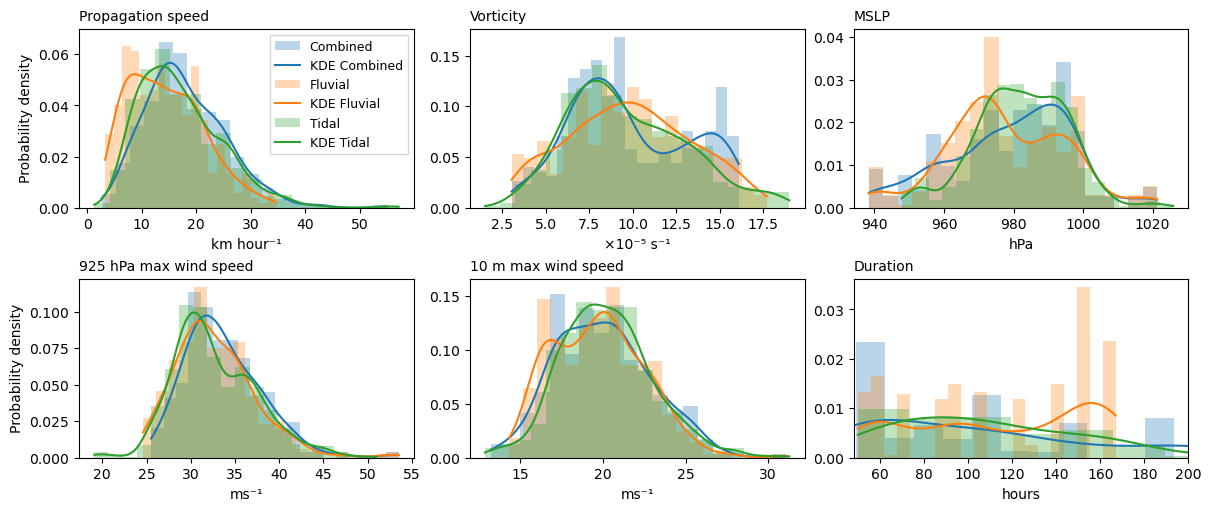

In [305]:
closure_types = ['Combined', 'Fluvial', 'Tidal']
colors = ['tab:blue', 'tab:orange', 'tab:green']
#fig, axs = plt.subplots(1, 5, figsize=(13., 3.))
fig, axs = plt.subplots(2, 3, figsize=(12., 5.), constrained_layout=True)
axs = axs.flatten()

for i, closure_type in enumerate(closure_types):
    ids_type = filtered_trx[filtered_trx['closure_type'] == closure_type]['uniq_id']
    storm_closure_new = storm_closure[storm_closure['uniq_id'].isin(ids_type)]
    northsea_bound = storm_closure_new[(storm_closure_new['lon_vor'] >= -10) & (storm_closure_new['lon_vor'] <= 10) & 
                                       (storm_closure_new['lat_vor'] >= 50) & (storm_closure_new['lat_vor'] <= 60)]
    
    kde_speed = gaussian_kde(northsea_bound['speed'])
    x_grid_speed = np.linspace(min(northsea_bound['speed']), max(northsea_bound['speed']), 100)
    kde_val_speed = kde_speed(x_grid_speed)
    mean_speed = np.sum(x_grid_speed * kde_val_speed) * (x_grid_speed[1] - x_grid_speed[0])
    var_speed = np.sum((x_grid_speed - mean_speed)**2 * kde_val_speed) * (x_grid_speed[1] - x_grid_speed[0])
    std_speed = np.sqrt(var_speed)

    kde_vor = gaussian_kde(northsea_bound['var_vor'])
    x_grid_vor = np.linspace(min(northsea_bound['var_vor']), max(northsea_bound['var_vor']), 100)
    kde_val_vor = kde_vor(x_grid_vor)
    mean_vor = np.sum(x_grid_vor * kde_val_vor) * (x_grid_vor[1] - x_grid_vor[0])
    var_vor = np.sum((x_grid_vor - mean_vor)**2 * kde_val_vor) * (x_grid_vor[1] - x_grid_vor[0])
    std_vor = np.sqrt(var_vor)
    
    kde_mslp = gaussian_kde(northsea_bound['var_mslp'])
    x_grid_mslp = np.linspace(min(northsea_bound['var_mslp']), max(northsea_bound['var_mslp']), 100)
    kde_val_mslp = kde_mslp(x_grid_mslp)
    mean_mslp = np.sum(x_grid_mslp * kde_val_mslp) * (x_grid_mslp[1] - x_grid_mslp[0])
    var_mslp = np.sum((x_grid_mslp - mean_mslp)**2 * kde_val_mslp) * (x_grid_mslp[1] - x_grid_mslp[0])
    std_mslp = np.sqrt(var_mslp)

    kde_wind = gaussian_kde(northsea_bound['var_wind'])
    x_grid_wind = np.linspace(min(northsea_bound['var_wind']), max(northsea_bound['var_wind']), 100)
    kde_val_wind = kde_wind(x_grid_wind)
    mean_wind = np.sum(x_grid_wind * kde_val_wind) * (x_grid_wind[1] - x_grid_wind[0])
    var_wind = np.sum((x_grid_wind - mean_wind)**2 * kde_val_wind) * (x_grid_wind[1] - x_grid_wind[0])
    std_wind = np.sqrt(var_wind)

    kde_prec = gaussian_kde(northsea_bound['var_prec'])
    x_grid_prec = np.linspace(min(northsea_bound['var_prec']), max(northsea_bound['var_prec']), 100)
    kde_val_prec = kde_prec(x_grid_prec)
    mean_prec = np.sum(x_grid_prec * kde_val_prec) * (x_grid_prec[1] - x_grid_prec[0])
    var_prec = np.sum((x_grid_prec - mean_prec)**2 * kde_val_prec) * (x_grid_prec[1] - x_grid_prec[0])
    std_prec = np.sqrt(var_prec)

    kde_dur = gaussian_kde(northsea_bound['duration_hours'])
    x_grid_dur = np.linspace(min(northsea_bound['duration_hours']), max(northsea_bound['duration_hours']), 100)
    kde_val_dur = kde_dur(x_grid_dur)
    mean_dur = np.sum(x_grid_dur * kde_val_dur) * (x_grid_dur[1] - x_grid_dur[0])
    var_dur = np.sum((x_grid_dur - mean_dur)**2 * kde_val_dur) * (x_grid_dur[1] - x_grid_dur[0])
    std_dur = np.sqrt(var_dur)

    axs[0].hist(northsea_bound['speed'], bins=20, density=True, alpha=0.3, color=colors[i], label=closure_type)
    axs[0].plot(x_grid_speed, kde_val_speed, label=f'KDE {closure_type}', color=colors[i], linewidth=1.5)
    #axs[0].set_title(f'μ= {mean_speed:.2f}, σ= {std_speed:.2f}, σ²= {var_speed:.2f}', fontsize=10, loc='left')
    axs[0].set_title('Propagation speed', loc='left', fontsize=10)
    axs[0].set_ylim(0,0.07)
    axs[0].set_xlabel('km hour⁻¹')
    axs[0].set_ylabel('Probability density')
    axs[0].legend(fancybox=False, framealpha=None, loc='upper right', fontsize=9, ncols=1)
    axs[1].hist(northsea_bound['var_vor'], bins=20, density=True, alpha=0.3, color=colors[i], label=closure_type)
    axs[1].plot(x_grid_vor, kde_val_vor, label=f'KDE {closure_type}', color=colors[i], linewidth=1.5)
    #axs[1].set_title(f'{closure_type} μ= {mean_vor:.2f}, σ= {std_vor:.2f}, σ²= {var_vor:.2f}', fontsize=10, loc='left')
    axs[1].set_title('Vorticity', loc='left', fontsize=10)
    axs[1].set_xlabel('×10⁻⁵ s⁻¹')
    axs[2].hist(northsea_bound['var_mslp'], bins=20, density=True, alpha=0.3, color=colors[i], label=closure_type)
    axs[2].plot(x_grid_mslp, kde_val_mslp, label=f'KDE {closure_type}', color=colors[i], linewidth=1.5)
    axs[2].set_title('MSLP', loc='left', fontsize=10)
    axs[2].set_xlabel('hPa')
    axs[3].set_ylabel('Probability density')
    axs[3].hist(northsea_bound['var_wind'], bins=20, density=True, alpha=0.3, color=colors[i], label=closure_type)
    axs[3].plot(x_grid_wind, kde_val_wind, label=f'KDE {closure_type}', color=colors[i], linewidth=1.5)
    axs[3].set_title('925 hPa max wind speed', loc='left', fontsize=10)
    axs[3].set_xlabel('ms⁻¹')
    axs[4].hist(northsea_bound['var_prec'], bins=20, density=True, alpha=0.3, color=colors[i], label=closure_type)
    axs[4].plot(x_grid_prec, kde_val_prec, label=f'KDE {closure_type}', color=colors[i], linewidth=1.5)
    axs[4].set_title('10 m max wind speed', loc='left', fontsize=10)
    axs[4].set_xlabel('ms⁻¹')
    axs[5].hist(northsea_bound['duration_hours'], bins=20, density=True, alpha=0.3, color=colors[i], label=closure_type)
    axs[5].plot(x_grid_dur, kde_val_dur, label=f'KDE {closure_type}', color=colors[i], linewidth=1.5)
    axs[5].set_title('Duration', loc='left', fontsize=10)
    axs[5].set_xlim(48,200)
    axs[5].set_xlabel('hours')
    
#plt.tight_layout()
plt.show()

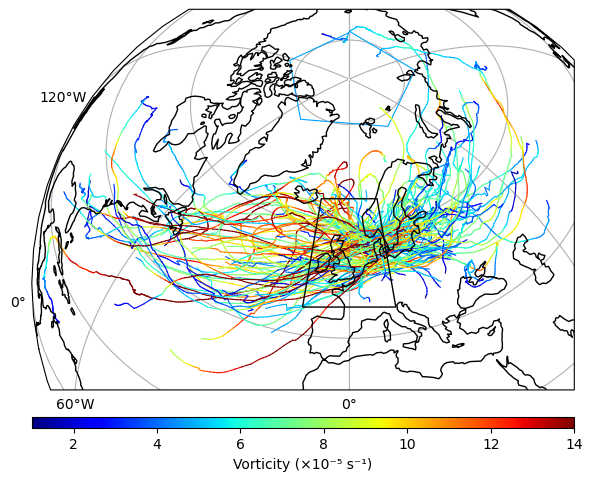

In [36]:
def plot_track_var(data_trx, var, filtered_trx):  
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180
    n_storm = data_trx['uniq_id'].nunique()

    fig, ax = plt.subplots(figsize=(7., 7.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    cmap = plt.cm.jet
    norm = Normalize(1, 14)

    # Processing each group
    for name, group in data_trx.groupby('unique_identifier'):
        # Ensure the 'Speed' data is numeric and handle NaNs
        group[var] = pd.to_numeric(group[var], errors='coerce')
        group[var].fillna(group[var].mean(), inplace=True)

        points = group[['lon_vor', 'lat_vor']].values
        color_values = norm(group[var].values)  # Normalize speed values
        colors = cmap(color_values)  # Convert normalized values to colors

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group[var].iloc[i] + group[var].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.8, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-12, 45], width=24, height=20, zorder=18, facecolor='none', edgecolor='black', transform=datacrs))
                                
    #ax.set_title(f"North Sea's Storm within Thames Barrier Closure Date Window")
    labelin = 'Vorticity (×10⁻⁵ s⁻¹)'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                orientation='horizontal', label=labelin)
    plt.show()

import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_var(storm_closure, 'var_vor', filtered_trx)

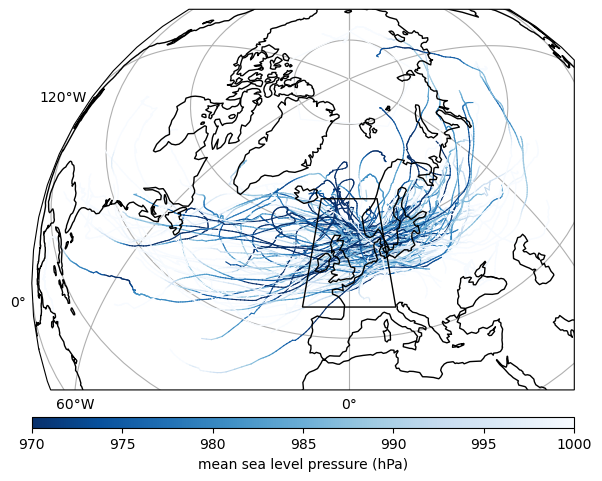

In [29]:
def plot_track_var(data_trx, var, filtered_trx):  
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50) 
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180
    n_storm = data_trx['unique_identifier'].nunique()

    fig, ax = plt.subplots(figsize=(7., 7.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    cmap = plt.cm.Blues_r
    norm = Normalize(970, 1000)

    # Processing each group
    for name, group in data_trx.groupby('unique_identifier'):
        # Ensure the 'Speed' data is numeric and handle NaNs
        group[var] = pd.to_numeric(group[var], errors='coerce')
        group[var].fillna(group[var].mean(), inplace=True)

        points = group[['lon_vor', 'lat_vor']].values
        color_values = norm(group[var].values)  # Normalize speed values
        colors = cmap(color_values)  # Convert normalized values to colors

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group[var].iloc[i] + group[var].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.8, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-12, 45], width=24, height=20, zorder=18, facecolor='none', edgecolor='black', transform=datacrs))
                                
    #ax.set_title(f"North Sea's Storm within Thames Barrier Closure Date Window")
    labelin = 'mean sea level pressure (hPa)'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                orientation='horizontal', label=labelin)
    plt.show()

warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plot_track_var(storm_closure, 'var_mslp', filtered_trx)

In [204]:
def plot_storm_dir(storm_data, filtered_data, closure_type):
    ids_to_plot = filtered_data[filtered_data['closure_type'] == closure_type]['uniq_id']
    sel_storm = storm_data[storm_data['uniq_id'].isin(ids_to_plot)]

    trx_all = sel_storm.dropna(subset=['bearing', 'speed'])
    northsea_bound = sel_storm[(sel_storm['lon_vor'] >= -4) & (sel_storm['lon_vor'] <= 10) & 
                      (sel_storm['lat_vor'] >= 50) & (sel_storm['lat_vor'] <= 60)]
    trx_north = northsea_bound.dropna(subset=['bearing', 'speed'])

    fig = plt.figure(figsize=(4., 4.))
    ax = WindroseAxes.from_ax(fig=fig)
    ax.contour(trx_north['bearing'].values, trx_north['speed'].values, bins=np.arange(0, 22, 5), 
           cmap=cm.Greens, lw=1.3, alpha=1, normed=True, nsector=32)
    ax.contour(trx_all['bearing'].values, trx_all['speed'].values, bins=np.arange(0, 22, 5), 
           cmap=cm.Reds, lw=1.4, alpha=1, normed=True, nsector=32)
    ax.set_yticklabels([5, 10, 15, 20, 25], fontsize=7)
    ax.set_legend(title="Propagation speed\n(km hour⁻¹)", title_fontsize=9, loc="lower left", fontsize=8)
    plt.title(f'{closure_type} Storm', fontsize=11, loc='left')
    #plt.tight_layout()
    plt.show()

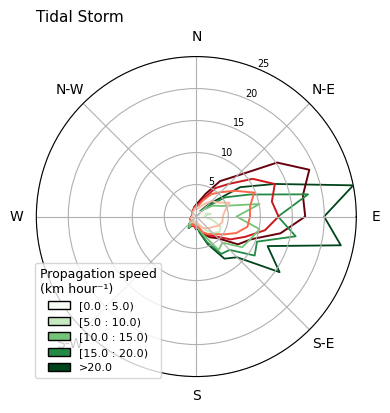

In [207]:
plot_storm_dir(storm_closure, filtered_trx, 'Tidal')

### Statistical

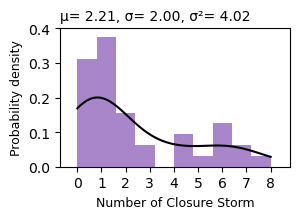

In [347]:
#filtered_storm = filtered_trx.drop_duplicates(subset=['uniq_id'])
#season_counts = filtered_storm['season'].value_counts().sort_index()
season_counts_list = season_counts.tolist()

kde_trx = gaussian_kde(season_clos)
x_trx = np.linspace(min(season_clos), max(season_clos), 100)
kde_values_trx = kde_trx(x_trx)

mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
variance_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
std_trx = np.sqrt(variance_trx)

# Plot the results
fig, axs = plt.subplots(1, 1, figsize=(3.1, 2.3))
axs.set_xticks(np.arange(0,11,1))
axs.set_yticks(np.arange(0,0.8,0.1))
axs.set_ylim(0,0.4)
axs.set_xlim(-0.7,8.8)
axs.hist(season_clos, bins=10, density=True, alpha=0.8, color='tab:purple')
axs.plot(x_trx, kde_values_trx, label='KDE', color='black')
axs.set_title(f'μ= {mean_trx:.2f}, σ= {std_trx:.2f}, σ²= {variance_trx:.2f}', fontsize=10, loc='left')
axs.set_xlabel('Number of Closure Storm', fontsize=9)
axs.set_ylabel('Probability density', fontsize=9)
plt.tight_layout()
plt.show()

In [47]:
freq_tidal = tidal_storm.drop_duplicates(subset=['uniq_id'])
year_freq_tidal= freq_tidal['season'].value_counts().sort_index()
year_freq_tidal = year_freq_tidal.values.tolist()

freq_fluv = fluv_storm.drop_duplicates(subset=['uniq_id'])
year_freq_fluv= freq_fluv['season'].value_counts().sort_index()
year_freq_fluv = year_freq_fluv.values.tolist()

freq_com = com_storm.drop_duplicates(subset=['uniq_id'])
year_freq_com= freq_com['season'].value_counts().sort_index()
year_freq_com = year_freq_com.values.tolist()

year_freq_clos = [year_freq_com, year_freq_fluv, year_freq_tidal]

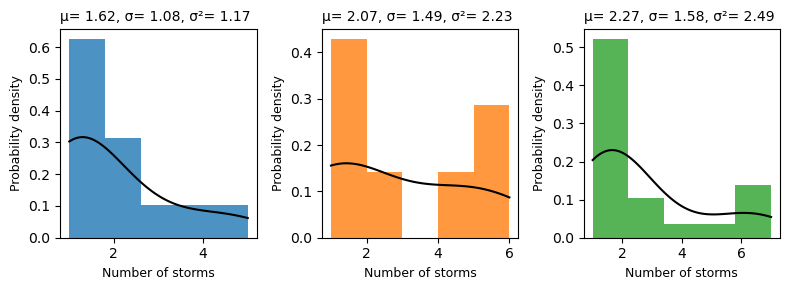

In [51]:
north_trx_title_b = ['Combined', 'Fluvial', 'Tidal',]
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axs = plt.subplots(1, 3, figsize=(8., 3.))
fig.subplots_adjust(wspace=0.95)
for i, (data, color) in enumerate(zip(year_freq_clos, colors)):
    kde_trx = gaussian_kde(data)
    x_trx = np.linspace(min(data), max(data), 100)
    kde_values_trx = kde_trx(x_trx)
    mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
    var_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
    std_trx = np.sqrt(var_trx)

    axs[i].hist(data, bins=5, density=True, alpha=0.8, color=color)
    axs[i].plot(x_trx, kde_values_trx, label='KDE', color='black')
    axs[i].set_title(f'μ= {mean_trx:.2f}, σ= {std_trx:.2f}, σ²= {var_trx:.2f}', fontsize=10, loc='left')
    axs[i].set_xlabel('Number of storms', fontsize=9)
    axs[i].set_ylabel('Probability density', fontsize=9)

plt.tight_layout()
plt.show()

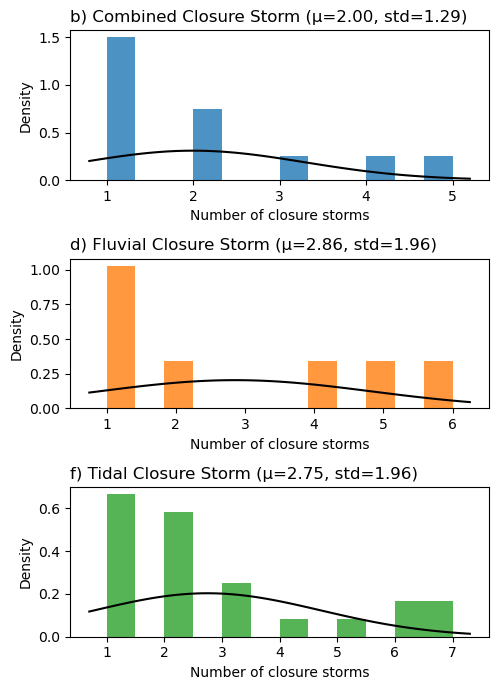

In [78]:
north_trx_title_b = ['b) Combined', 'd) Fluvial', 'f) Tidal',]
colors = ['tab:blue', 'tab:orange',  'tab:green',]

from scipy.stats import norm
fig, axs = plt.subplots(3, 1, figsize=(5., 7.))
fig.subplots_adjust(hspace=0.05)
for i, (data, color) in enumerate(zip(year_freq_clos, colors)):
    # Fit a normal distribution to the data
    mu, std = norm.fit(data)

    axs[i].hist(data, bins=12, density=True, alpha=0.8, color=color)
    xmin, xmax = axs[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    axs[i].plot(x, p, 'k', linewidth=1.5)
    title = f"{north_trx_title_b[i]} Closure Storm (μ={mu:.2f}, std={std:.2f})"
    axs[i].set_title(title, loc='left')
    axs[i].set_xlabel('Number of closure storms')
    axs[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

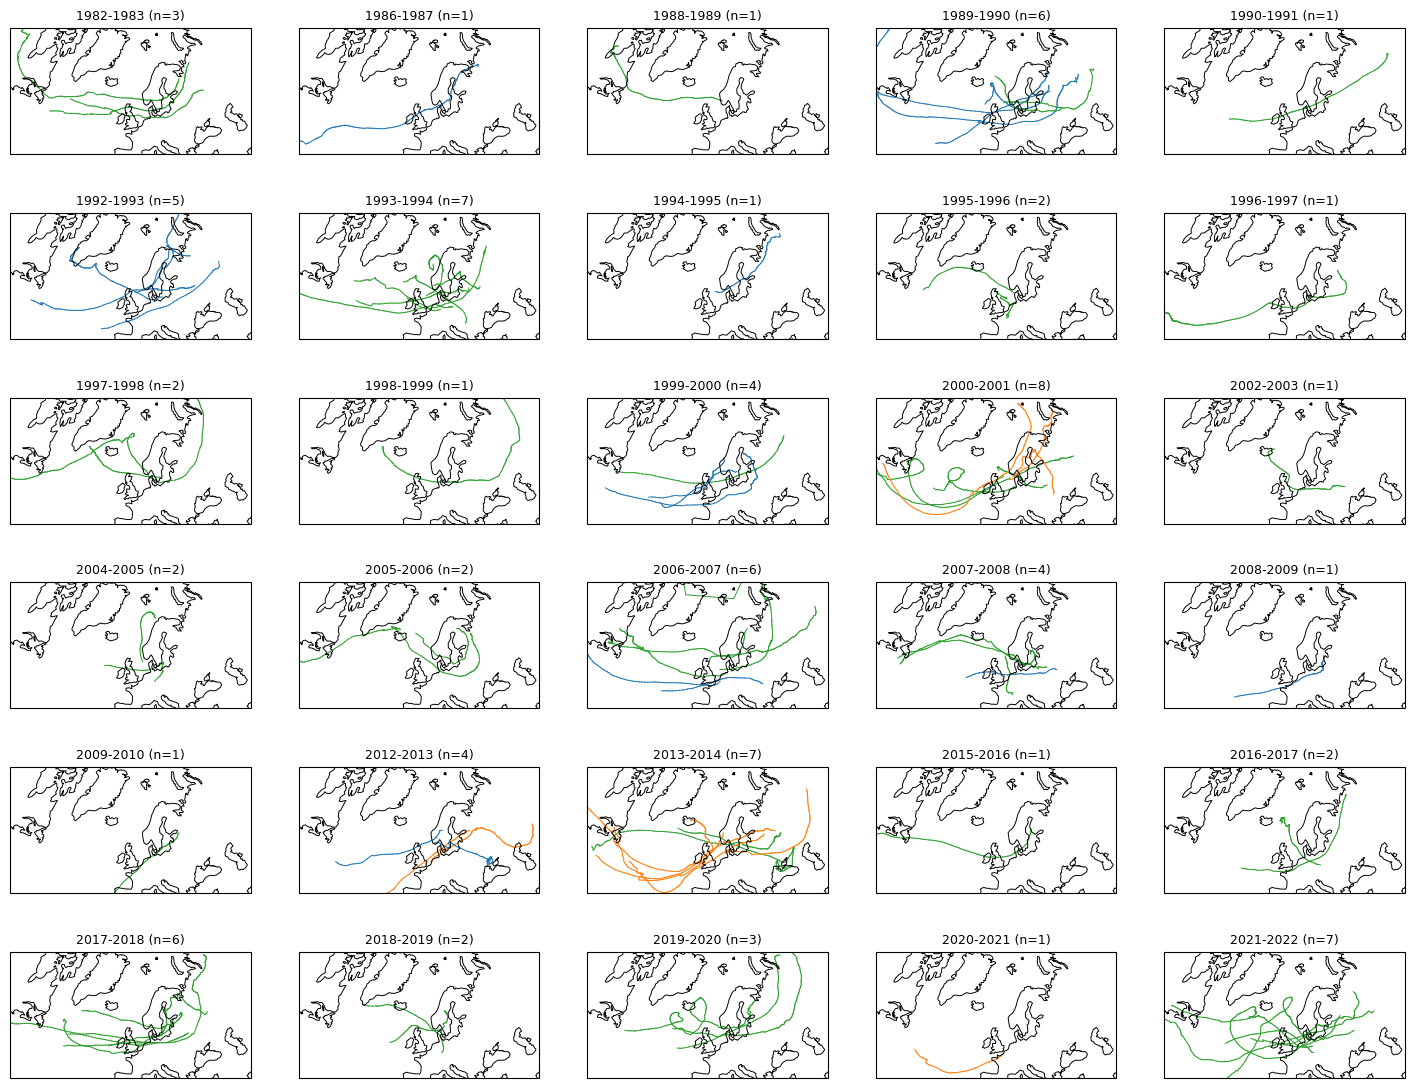

In [20]:
datacrs = ccrs.PlateCarree()
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
boundary = [-70, 60, 80, 40]

# Get unique seasons in the data
unique_seasons = sorted(storm_closure['season'].unique())

# Determine the number of rows and columns for subplots
n_seasons = len(unique_seasons)
n_cols = 5  # Number of columns in the plot
n_rows = (n_seasons // n_cols) + (n_seasons % n_cols > 0)

color_mapping = {
        'Combined': 'tab:blue',
        'Fluvial': 'tab:orange',
        'Tidal': 'tab:green' }

unique_ids = filtered_trx['uniq_id'].unique()
identifier_colors = {uid: color_mapping[filtered_trx[filtered_trx['uniq_id'] == uid]['closure_type'].values[0]] for uid in unique_ids}


fig, axs = plt.subplots(n_rows, n_cols, sharey=True, sharex=True, figsize=(18., 14.), subplot_kw={'projection': mapcrs})
axs = axs.ravel()

for i, season in enumerate(unique_seasons):
    ax = axs[i]
    trx_season = storm_closure[storm_closure['season'] == season]
    
    n_storm = trx_season['uniq_id'].nunique()
    ax.set_extent(boundary, crs=datacrs)
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')

    cmap = plt.cm.viridis
    norm = Normalize(2, 20)

    for idx, group in trx_season.groupby('uniq_id'):
        storm_color = identifier_colors[idx]
        points = group[['lon_vor', 'lat_vor']].values
        for j in range(len(points) - 1):
            line = np.array([points[j], points[j + 1]])
            #mid_value = norm((group['speed'].iloc[j] + group['speed'].iloc[j + 1]) / 2)
            #ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.8, transform=datacrs)
            ax.plot(line[:, 0], line[:, 1], color=storm_color, linewidth=0.7, transform=datacrs)

    ax.set_title(f'{season} (n={n_storm})', fontsize=9)

# Hide any remaining empty subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

#fig.subplots_adjust(bottom=0.05, right=0.8, top=0.95, wspace=0.05, hspace=0.05)
#cax = fig.add_axes([0.82, 0.15, 0.02, 0.75])
#labelin = 'Track translation speed (km/h)'
#plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, pad=0.05, aspect=50, orientation='vertical', label=labelin)

plt.show()


## Closure Storm Freq & SSI

In [310]:
northsea_bound = storm_closure_new[(storm_closure_new['lon_vor'] >= -10) & (storm_closure_new['lon_vor'] <= 10) & 
                                       (storm_closure_new['lat_vor'] >= 50) & (storm_closure_new['lat_vor'] <= 60)]
print(northsea_bound)
vor_perc = northsea_bound.groupby('season')['var_vor'].apply(lambda x: x.quantile(0.9))
vor_mean = northsea_bound['var_vor'].mean()
vor_std = northsea_bound['var_vor'].std()
print('mean:', vor_mean, 'std:', vor_std)
ssi = (vor_perc.values - vor_mean) / vor_std

       Unnamed: 0                date   lon_vor    lat_vor   var_vor  \
154        1432.0 1983-01-29 17:00:00  5.404084  59.932278  8.716770   
155        1433.0 1983-01-29 18:00:00  6.257935  59.840279  8.792710   
156        1434.0 1983-01-29 19:00:00  6.986310  59.774853  8.814789   
157        1435.0 1983-01-29 20:00:00  7.640089  59.730110  8.813180   
158        1436.0 1983-01-29 21:00:00  8.313119  59.700153  8.748779   
...           ...                 ...       ...        ...       ...   
11042      1626.0 2022-02-20 20:00:00  4.435795  54.167831  8.264236   
11043      1627.0 2022-02-20 21:00:00  6.221174  54.795967  8.778368   
11044      1628.0 2022-02-20 22:00:00  7.403742  55.014763  8.851241   
11045      1629.0 2022-02-20 23:00:00  8.824114  55.751862  9.219216   
11046      1630.0 2022-02-21 00:00:00  9.887537  56.196266  9.771890   

        lon_mslp  lat_mslp  var_mslp  lon_wind  lat_wind  ...  median_time  \
154     4.519814  60.61383  973.3395   4.50000  58.87585 

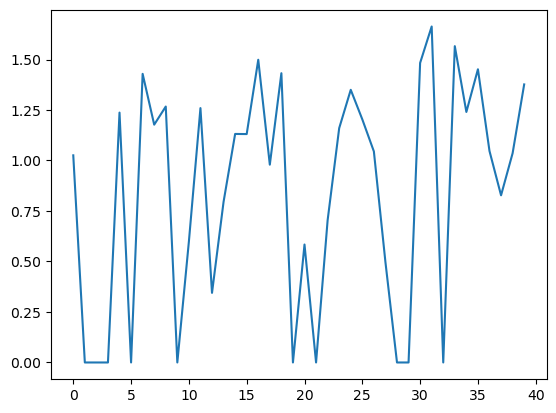

In [391]:
vor_perc_clos = storm_closure.groupby('season')['var_mslp'].apply(lambda x: x.quantile(0.9))
vor_mean_clos = storm_closure['var_mslp'].mean()
vor_std_clos = storm_closure['var_mslp'].std()
ssi_clos = (vor_perc_clos.values - vor_mean_clos) / vor_std_clos
ssi_clos = np.nan_to_num(ssi_clos, nan=0)

slope_clos_si, intercept_clos_si, r_value_clos_si, p_value_clos_si, std_clos_si = linregress(range_season, ssi_clos)
Y_pred_clos_si = intercept_clos_si + slope_clos_si * range_season


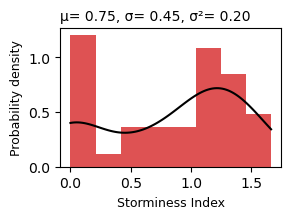

In [392]:
kde_ssi_clos = gaussian_kde(ssi_clos)
x_ssi_clos = np.linspace(min(ssi_clos), max(ssi_clos), 100)
kde_ssi_clos_val = kde_ssi_clos(x_ssi_clos)

mean_ssi_clos = np.sum(x_ssi_clos * kde_ssi_clos_val) * (x_ssi_clos[1] - x_ssi_clos[0])
var_ssi_clos = np.sum((x_ssi_clos - mean_ssi_clos)**2 * kde_ssi_clos_val) * (x_ssi_clos[1] - x_ssi_clos[0])
std_ssi_clos = np.sqrt(var_ssi_clos)

# Plot the results
fig, axs = plt.subplots(1, 1, figsize=(3.1, 2.3))
#axs.set_xticks(np.arange(0,11,1))
#axs.set_yticks(np.arange(0,0.8,0.1))
#axs.set_ylim(0,0.4)
#axs.set_xlim(-0.7,8.8)
axs.hist(ssi_clos, bins=8, density=True, alpha=0.8, color='tab:red')
axs.plot(x_ssi_clos, kde_ssi_clos_val, label='KDE', color='black')
axs.set_title(f'μ= {mean_ssi_clos:.2f}, σ= {std_ssi_clos:.2f}, σ²= {var_ssi_clos:.2f}', fontsize=10, loc='left')
axs.set_xlabel('Storminess Index', fontsize=9)
axs.set_ylabel('Probability density', fontsize=9)
plt.tight_layout()
plt.show()

In [353]:
data = {
    'season': [
        '1982-1983', '1986-1987', '1988-1989', '1989-1990', '1990-1991', '1992-1993', '1993-1994',
        '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999', '1999-2000', '2000-2001',
        '2002-2003', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010',
        '2012-2013', '2013-2014', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020',
        '2020-2021', '2021-2022'
    ],
    'Northerly': [
        0, 0, 0, 2, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 3],
    'Westerly': [
        3, 1, 1, 4, 1, 5, 6, 1, 1, 1, 1, 1, 4, 7, 0, 1, 1, 6, 2, 1, 1, 4, 6, 1, 1, 6, 1, 3, 1, 4]}

df = pd.DataFrame(data)
df.set_index('season', inplace=True)

new_seasons = ['1983-1984', '1984-1985', '1985-1986', '1987-1988', '1991-1992', 
               '2001-2002', '2003-2004', 
               '2010-2011', '2011-2012', '2014-2015']

new_data = pd.DataFrame(0, index=new_seasons, columns=['Northerly', 'Westerly'])
df = pd.concat([df, new_data])
df = df.sort_index()


           Northerly  Westerly
1982-1983          0         3
1983-1984          0         0
1984-1985          0         0
1985-1986          0         0
1986-1987          0         1
1987-1988          0         0
1988-1989          0         1
1989-1990          2         4
1990-1991          0         1
1991-1992          0         0
1992-1993          0         5
1993-1994          1         6
1994-1995          0         1
1995-1996          1         1
1996-1997          0         1
1997-1998          1         1
1998-1999          0         1
1999-2000          0         4
2000-2001          1         7
2001-2002          0         0
2002-2003          1         0
2003-2004          0         0
2004-2005          1         1
2005-2006          1         1
2006-2007          0         6
2007-2008          2         2
2008-2009          0         1
2009-2010          0         1
2010-2011          0         0
2011-2012          0         0
2012-2013          0         4
2013-201

In [346]:
closure_all = {
    'season': ['1982-1983', '1983-1984', '1984-1985', '1985-1986', '1986-1987', '1987-1988', '1988-1989', '1989-1990',
               '1990-1991', '1991-1992', '1992-1993', '1993-1994', '1994-1995', '1995-1996', '1996-1997', '1997-1998',
               '1998-1999', '1999-2000', '2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2005-2006',
               '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014',
               '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022'],
    'closure_n': [3, 0, 0, 0, 1, 0, 1, 6, 1, 0, 5, 7, 1, 2, 1, 1, 1, 4, 8, 0, 1, 0, 2, 2, 6, 4, 1, 1, 0, 0, 4, 6, 0, 1, 2, 6, 2, 3, 1, 7]
}
closure_all = pd.DataFrame(closure_all)
season_clos = closure_all['closure_n'].values

In [357]:
slope_clos, intercept_clos, r_value_clos, p_value_clos, std_clos = linregress(range_season, season_clos)
Y_pred_clos = intercept_clos + slope_clos * range_season

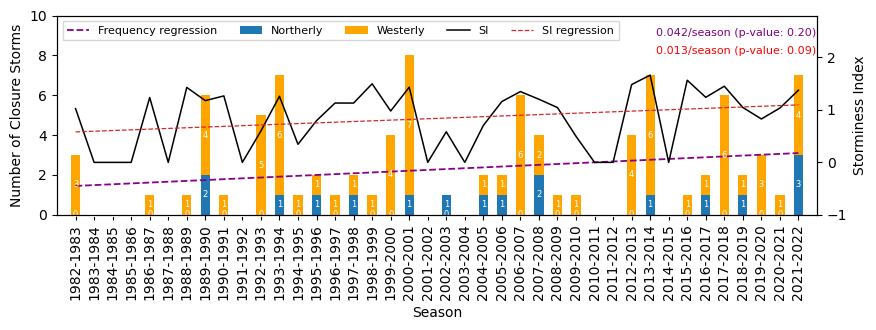

In [395]:
fig, ax1 = plt.subplots(figsize=(9., 3.4))

color_mapping = {'Northerly': 'tab:blue',
                 'Westerly': 'orange'}

colors = [color_mapping.get(col, 'tab:gray') for col in season_counts_bar.columns]
#season_counts_bar.plot(kind='bar', stacked=True, ax=ax1, width=0.8, color=colors, legend=False)
#ax1.bar(closure_all['season'].values, season_clos, color='mediumpurple', label='Frequency')
df.plot(kind='bar', ax=ax1, stacked=True, color=colors, legend=False)
ax1.plot(range_season, Y_pred_clos, color='darkmagenta', linewidth=1.3, linestyle='--', label='Frequency regression')
ax1.set_xlabel('Season')
ax1.set_ylabel('Number of Closure Storms')
ax1.set_ylim(0, 10)
ax1.set_xlim(-1,40)
slope_freq = f'{slope_clos:.3f}/season (p-value: {p_value_clos:.2f})'

ax2 = ax1.twinx()

ax2.set_ylim(-1, 2.8)
ax2.plot(closure_all['season'].values, ssi_clos, color='black', linewidth=1.1, label='SI')
ax2.plot(range_season, Y_pred_clos_si, color='tab:red', linewidth=0.9, linestyle='--', label='SI regression')
ax2.set_ylabel('Storminess Index')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, fontsize=8, fancybox=False, ncol=5, loc='upper left')

slope_si = f'{ slope_clos_si:.3f}/season (p-value: {p_value_clos_si:.2f})'
ax2.text(31.3, 2.4, slope_freq, fontsize=8, color='purple')
ax2.text(31.3, 2.07, slope_si, fontsize=8, color='red')
for container in ax1.containers:
    ax1.bar_label(container, label_type='center', fontsize=6, color='white')
plt.setp(ax1.get_xticklabels(), rotation=90, ha='center')
plt.tight_layout()
plt.show()

In [331]:
merged_data = storm_closure.drop_duplicates(subset=['uniq_id'])
season_counts_bar = merged_data.groupby(['season', 'category']).size().unstack(fill_value=0)
season_counts_bar

category,Northerly,Westerly
season,,
1982-1983,0,3
1986-1987,0,1
1988-1989,0,1
1989-1990,2,4
1990-1991,0,1
1992-1993,0,5
1993-1994,1,6
1994-1995,0,1
1995-1996,1,1


In [358]:
storm_closure['season'] = pd.to_datetime(storm_closure['season'].str.split('-').str[0], format='%Y')  # Convert to datetime for accurate sorting
storm_closure = storm_closure.sort_values(by='season')
storm_closure['season'] = storm_closure['season'].dt.strftime('%Y') + '-' + (storm_closure['season'].dt.year + 1).astype(str)

In [164]:
filtered_closure = filtered_trx.drop_duplicates(subset=['closure_ID'])
season_closure_counts = filtered_closure['season'].value_counts().sort_index()
season_closure_counts

season
1982-1983     1
1986-1987     1
1988-1989     1
1989-1990     3
1990-1991     1
1992-1993     2
1993-1994     3
1994-1995     3
1995-1996     3
1996-1997     1
1997-1998     1
1998-1999     1
1999-2000     6
2000-2001    16
2002-2003     1
2004-2005     2
2005-2006     2
2006-2007     8
2007-2008     6
2008-2009     4
2009-2010     5
2012-2013     5
2013-2014    18
2015-2016     1
2016-2017     2
2017-2018     4
2018-2019     2
2019-2020     6
2021-2022     5
Name: count, dtype: int64

In [351]:
val_season_clos = [x for x in season_clos if x != 0]
val_ssi_clos = [x for x in ssi_clos if x != 0]
print(val_ssi_clos)

[1.1295474682433486, 1.8856530748548397, 1.422757955960498, 0.9684631334555548, 1.4892557610090713, 0.42794816865961816, 1.051699715151345, 0.05924803165837953, 1.9981564240013023, 2.866022862275706, 1.9174743042777085, 0.41562139584517926, 1.7993609115547144, 1.2708881675404462, 1.0522815662981466, 1.8863998413654772, 0.48696391502255987, 0.7912319646066776, 1.4488310484264884, 1.9389433103301439, 1.7260455425441632, -0.0029999496100626796, 1.6791777115116941, 2.6803186022858645, 0.9709743084642976, 0.5467116094141711, 1.1602727142418219, 0.8235665296145614, -0.4231134205963565, 1.841721587104062]
[3, 1, 1, 6, 1, 5, 7, 1, 2, 1, 1, 1, 4, 8, 1, 2, 2, 6, 4, 1, 1, 4, 6, 1, 2, 6, 2, 3, 1, 7]


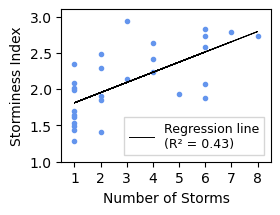

In [270]:
val_season_clos = np.array(val_season_clos)
val_ssi_clos = np.array(val_ssi_clos)

slope, intercept, r_value, p_value, std_err = linregress(val_season_clos, val_ssi_clos)
line = slope * val_season_clos + intercept

plt.figure(figsize=(2.7, 1.98))
plt.scatter(val_season_clos, val_ssi_clos, color='cornflowerblue', label='', s=9)
plt.plot(val_season_clos, line, color='black', linestyle='-', linewidth=0.7, label=f'Regression line\n(R² = {r_value**2:.2f})')
plt.xlabel('Number of Storms')
plt.ylabel('Storminess Index')
plt.xticks(np.arange(1,9,1))
plt.ylim(1,3.1)
plt.xlim(0.5,8.5)
plt.legend(fontsize=9, loc='lower right', fancybox=False)
plt.show()

## Closure Event

In [481]:
data_closure = {
    'season': [
        '1982-1983', '1986-1987', '1988-1989', '1989-1990', '1990-1991', '1992-1993', '1993-1994',
        '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999', '1999-2000', '2000-2001',
        '2002-2003', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010',
        '2012-2013', '2013-2014', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020',
        '2020-2021', '2021-2022'
    ],
    'count': [
        1, 1, 1, 3, 1, 2, 3, 3, 3, 1, 1, 1, 6, 16, 1, 2, 2, 8, 6, 4, 5, 5, 27, 1, 2, 4, 2, 6, 1, 6
    ]
}

data_closure = pd.DataFrame(data_closure)
#data_closure.set_index('season', inplace=True)

,season,count
0,1982-1983,1
1,1986-1987,1
2,1988-1989,1
3,1989-1990,3
4,1990-1991,1
5,1992-1993,2
6,1993-1994,3
7,1994-1995,3
8,1995-1996,3
9,1996-1997,1


In [483]:
noclos_season = ['1983-1984', '1984-1985', '1985-1986', '1987-1988', '1991-1992', 
                '2001-2002', '2003-2004', 
                 '2010-2011', '2011-2012', '2014-2015']

new_rows = [{'season': season} for season in noclos_season]
new_closure = pd.DataFrame(new_rows, columns=data_closure.columns)
closure_count_per_season = pd.concat([data_closure, new_closure], ignore_index=False)
count_closurefix = closure_count_per_season.sort_values(by='season')
count_closurefix['count'] = count_closurefix['count'].fillna(0)

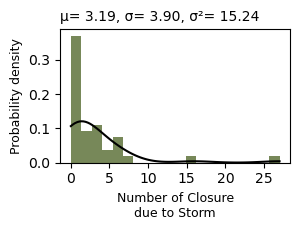

In [489]:
kde_clos = gaussian_kde(count_closurefix['count'].values)
x_clos = np.linspace(count_closurefix['count'].values.min(), count_closurefix['count'].values.max(), 100)
kde_values_clos = kde_clos(x_clos)

mean_clos = np.sum(x_clos * kde_values_clos) * (x_clos[1] - x_clos[0])
var_clos = np.sum((x_clos - mean_clos)**2 * kde_values_clos) * (x_clos[1] - x_clos[0])
std_clos = np.sqrt(var_clos)

# Plot the results
fig, axs = plt.subplots(1, 1, figsize=(3.1, 2.4))
axs.set_xticks(np.arange(0,28,5))
axs.set_yticks(np.arange(0,0.5,0.1))
#axs.set_ylim(0,0.4)
#axs.set_xlim(-0.7,8.8)
axs.hist(count_closurefix['count'].values, bins=20, density=True, alpha=0.8, color='darkolivegreen')
axs.plot(x_clos, kde_values_clos, label='KDE', color='black')
axs.set_title(f'μ= {mean_clos:.2f}, σ= {std_clos:.2f}, σ²= {var_clos:.2f}', fontsize=10, loc='left')
axs.set_xlabel('Number of Closure\ndue to Storm', fontsize=9)
axs.set_ylabel('Probability density', fontsize=9)
plt.tight_layout()
plt.show()

In [490]:
slope_c, intercept_c, r_value_c, p_value_c, std_clos_s = linregress(range_season, count_closurefix['count'].values)
Y_pred_c= intercept_c + slope_c * range_season

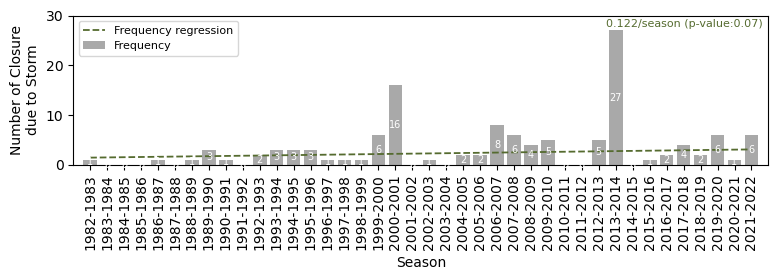

In [494]:
fig, ax = plt.subplots(figsize=(8., 2.9))
ax.bar(count_closurefix['season'].values, count_closurefix['count'].values, color='darkgrey', label='Frequency')
ax.plot(range_season, Y_pred_clos, color='darkolivegreen', linewidth=1.3, linestyle='--', label='Frequency regression')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Closure\ndue to Storm')
ax.set_ylim(0, 30)
ax.set_xlim(-1,40)
slope_clos_fre = f'{slope_c:.3f}/season (p-value:{p_value_c:.2f})'
ax.text(30.4, 27.72, slope_clos_fre, fontsize=8, color='darkolivegreen')
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7, color='white')
plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## Bin

In [91]:
def bin_wind_data(directions, speeds, direction_bins=36, speed_bins=9, speed_range=(0, 45)):
    direction_bins = np.linspace(0, 360, direction_bins + 1)
    speed_bins = np.linspace(speed_range[0], speed_range[1], speed_bins + 1)
    
    binned_data = pd.DataFrame(index=pd.IntervalIndex.from_breaks(direction_bins, closed='left'),
                               columns=pd.IntervalIndex.from_breaks(speed_bins, closed='left'))
    binned_data[:] = 0
    
    for d, s in zip(directions, speeds):
        dir_bin = np.digitize(d, direction_bins) - 1
        spd_bin = np.digitize(s, speed_bins) - 1
        if dir_bin < len(direction_bins) - 1 and spd_bin < len(speed_bins) - 1:
            binned_data.iloc[dir_bin, spd_bin] += 1
    
    binned_data /= len(directions) 
    
    return binned_data

In [97]:
def plot_storm_dir_diff (storm_closure, filtered_trx, closure_type):
    ids_to_plot = filtered_trx[filtered_trx['closure_type'] == closure_type]['uniq_id']
    storm_dir = storm_closure[storm_closure['uniq_id'].isin(ids_to_plot)]

    trx_dir_all = storm_dir.dropna(subset=['bearing', 'speed'])
    northsea_bound = storm_dir[(storm_dir['lon_vor'] >= -4) & (storm_dir['lon_vor'] <= 10) & 
                      (storm_dir['lat_vor'] >= 50) & (storm_dir['lat_vor'] <= 60)]
    trx_dir_north = northsea_bound.dropna(subset=['bearing', 'speed'])

    # Bin and normalize data for both datasets
    binned_all = bin_wind_data(trx_dir_all['bearing'].values, trx_dir_all['speed'].values)
    binned_north = bin_wind_data(trx_dir_north['bearing'].values, trx_dir_north['speed'].values)
    binned_diff = binned_all - binned_north

    # Prepare synthetic dataset for plotting
    synthetic_directions = []
    synthetic_speeds = []

    for i, dir_bin in enumerate(binned_diff.index):
        for j, spd_bin in enumerate(binned_diff.columns):
            value = binned_diff.iloc[i, j]
            if value != 0:
                count = int(abs(value * 1000))
                synthetic_directions.extend([dir_bin.left + (dir_bin.right - dir_bin.left) / 2] * count)
                synthetic_speeds.extend([spd_bin.left + (spd_bin.right - spd_bin.left) / 2] * count)

    # Convert to numpy arrays for plotting
    synthetic_directions = np.array(synthetic_directions)
    synthetic_speeds = np.array(synthetic_speeds)

    # Create windrose plot
    fig = plt.figure(figsize=(5., 5.))
    ax = WindroseAxes.from_ax(fig=fig)
    ax.contourf(synthetic_directions, synthetic_speeds, bins=np.arange(1, 45, 5), cmap=plt.cm.viridis_r)
    ax.set_legend(title="Difference in Storm \nPropagation Speed (km/h)", loc="lower left", fancybox=False)
    ax.set_title(f'{closure_type}')
    plt.show()

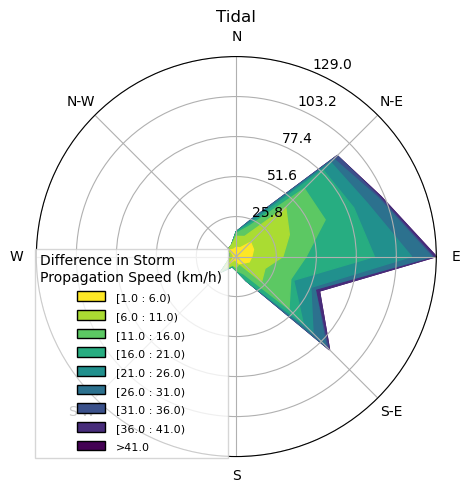

In [98]:
plot_storm_dir_diff(storm_closure, filtered_trx, 'Tidal')